# Chapter 3	Programming Examples for Conventional Control Mode

## Test Cases of Conventional Control Mode

### To Initialize the System

In [1]:
## Part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from time import time, sleep
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
%matplotlib widget

## Part 2
SHARED_DEVICE_MEM.clear_ip()

## Part 3
device_ip = "172.16.153.203"
qsync_ip = "172.16.153.203"
device = MCIDriver(device_ip, 50)
qsync = QSYNCDriver(qsync_ip)

## Part 4
da_rate_rd = 8e9
da_rate_xy = 8e9
da_rate_z = 2e9
ad_rate = 4e9

## "MixMode" is the DAC mix mode of PQ-XY and RD. 1 or 2 is available to choose. You should select it based on the output signal frequency settings. When the output signal frequency is greater than fs/2, 2 is selected.
## "INMixMode" is the ADC mode of PQ-RD. 1 or 2 is available to choose. You should select it based on the cavity resonant frequency settings. When the cavity resonant frequency is within 4 GHz~6 GHz, 1 is selected; when the cavity resonant frequency is within 6 GHz~8 GHz, 2 is selected.
## "RefClock": selects the reference clock for the business module. "in" or "out" is available to choose. By default, when PQ-S10 exists on the module, "out" is selected; for the single board test, "in" is selected.
## "DArate": DAC sample rate, expressed in Hz. The available choices for PQ-XY and PQ-RD are 6e9, 8e9, and 10e9. The available choices for PQ-ZC are 2e9 and 4e9.
## "ADrate": ADC sample rate, expressed in Hz. The value of PQ-RD is fixed to be 4e9.
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S2-O1": da_rate_rd,
    "DArate_S12-O1": da_rate_z,
    "DArate_S13-O1": da_rate_xy,
    "INMixMode": 2,
    "ADrate": ad_rate,
    "CaptureMode": 0,
}

##"RefClock": selects the reference clock. Both input reference clock and output reference clock can be selected. When working alone (i.e., 100M IN not connected), "in" (input reference clock) is selected. When working with 100M IN being connected, "out" (output reference clock) is selected.
qsync_param = {"RefClock": "in"}

## Part 5
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()


*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 14.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
设备172.16.153.203-板卡3-指令b'\x1a\x00\x001'-指令Resync执行失败
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


### To Play the Gaussian Pulse Signal

In [5]:
shots = 0xFFFFFFFF
trig_period = 100e-6
out_ch = "S13-O1"
device.set("Output", 0, "all")
device.set("Output", 1, out_ch)
qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

freq = 100e6
pulse_width = 2e-6
gaussian_delay = 75e-9
time_axis = np.linspace(0, pulse_width, round(pulse_width * da_rate_rd), endpoint=False)
gaussian_time_axis = np.linspace(
    -(pulse_width + gaussian_delay) / 2,
    (pulse_width + gaussian_delay) / 2,
    round(pulse_width * da_rate_rd),
    endpoint=False,
)
gaussian_sigma = pulse_width / (6 * np.sqrt(np.log(2)))  # 2*FWHM
envelope = np.exp(-((gaussian_time_axis / gaussian_sigma) ** 2))
wave = np.cos(2 * np.pi * freq * time_axis)
wave = envelope * np.cos(2 * np.pi * freq * time_axis)
wave = np.hstack(3 * (wave,))

device.set("Waveform", wave, out_ch)
qsync.set("GenerateTrig")


In [6]:
qsync.set("ResetTrig")

### To Play Square Signals

In [10]:
shots = 0xFFFFFFFF
trig_period = 100e-6
wave_width = 75e-6
wave = np.ones(round(da_rate_z * wave_width))
wave[-1] = 0
device.set("Output", 0, "all")

z_out_ch_list = [f"S12-O{idx}" for idx in range(1, 9)]
for z_out_ch in z_out_ch_list:
    device.set("Waveform", wave, z_out_ch)
    device.set("Output", 1, z_out_ch)

qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)
qsync.set("GenerateTrig")


In [344]:
keep_amp = 0  ## Keep Zero when play is over.
# keep_amp = 1  ## Keep the last value of 614.4KPoints.
# keep_amp = 2  ## Keep the first value of 614.4KPoints.
device.set("KeepAmp", keep_amp)  ## This instruction set is only valid for M6311-C8 board.
# Takes effect after the waveform is issued


In [8]:
qsync.set("ResetTrig")

### To Play Continuous Signals

In [9]:
shots = 0xFFFFFFFF
freq = 0.1e9  ## Signal frequency. It must be an integer multiple of 20 kHz (the frequency corresponding to 50 µs).
amplitude = 1
wave_width = 60e-6  ## Waveform length
trig_period = 50e-6  ## Trigger period, < waveform length for continuous waveform
time_axis = np.linspace(0, wave_width, round(wave_width * da_rate_xy), endpoint=False)
wave = amplitude * np.cos(2 * np.pi * freq * time_axis)

xy_out_ch = "S13-O1"
device.set("Output", 0, "all")
device.set("Output", 1, xy_out_ch)
qsync.set("TrigPeriod", trig_period)
qsync.set("Shot", shots)
device.set("Waveform", wave, xy_out_ch)
qsync.set("GenerateTrig")


In [11]:
qsync.set("ResetTrig")

### To Acquire the Raw Signal

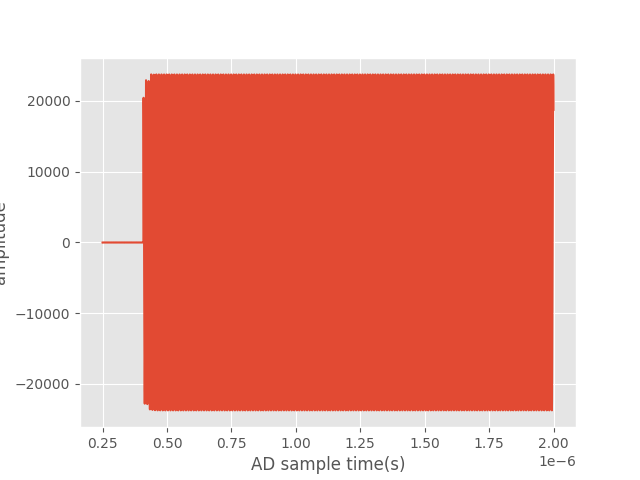

In [80]:
freq = 100e6
wave_width = 4.8e-6
rd_width = 2e-6
capture_mode = 1
shots = 1024
trig_period = 200e-6
rd_out_ch = "S2-O1"
rd_in_ch = "S2-I1"

time_axis = np.linspace(0, wave_width, round(wave_width * da_rate_rd), endpoint=False)
wave = np.cos(2 * np.pi * freq * time_axis)

device.set("Output", 0, "all")
device.set("Output", 1, rd_out_ch)
device.set("CaptureMode", capture_mode)
device.set("Shot", shots)
qsync.set("Shot", shots)
device.set("TriggerDelay", 0, rd_in_ch)
qsync.set("TrigPeriod", trig_period)
device.set("TimeWidth", rd_width, rd_in_ch)
device.set("Waveform", wave, rd_out_ch)
device.set("FreqList", [float(freq)], rd_in_ch)
device.set("StartCapture")
qsync.set("GenerateTrig")
data = device.get("TraceIQ", rd_in_ch)

rd_time_axis = np.linspace(0, rd_width, round(rd_width * ad_rate), endpoint=False)
plt.figure()
plt.plot(rd_time_axis[1000:], data.mean(axis=0)[1000:])
plt.ylabel("amplitude")
plt.xlabel("AD sample time(s)")
plt.show()


### To Acquire the Demodulation Data

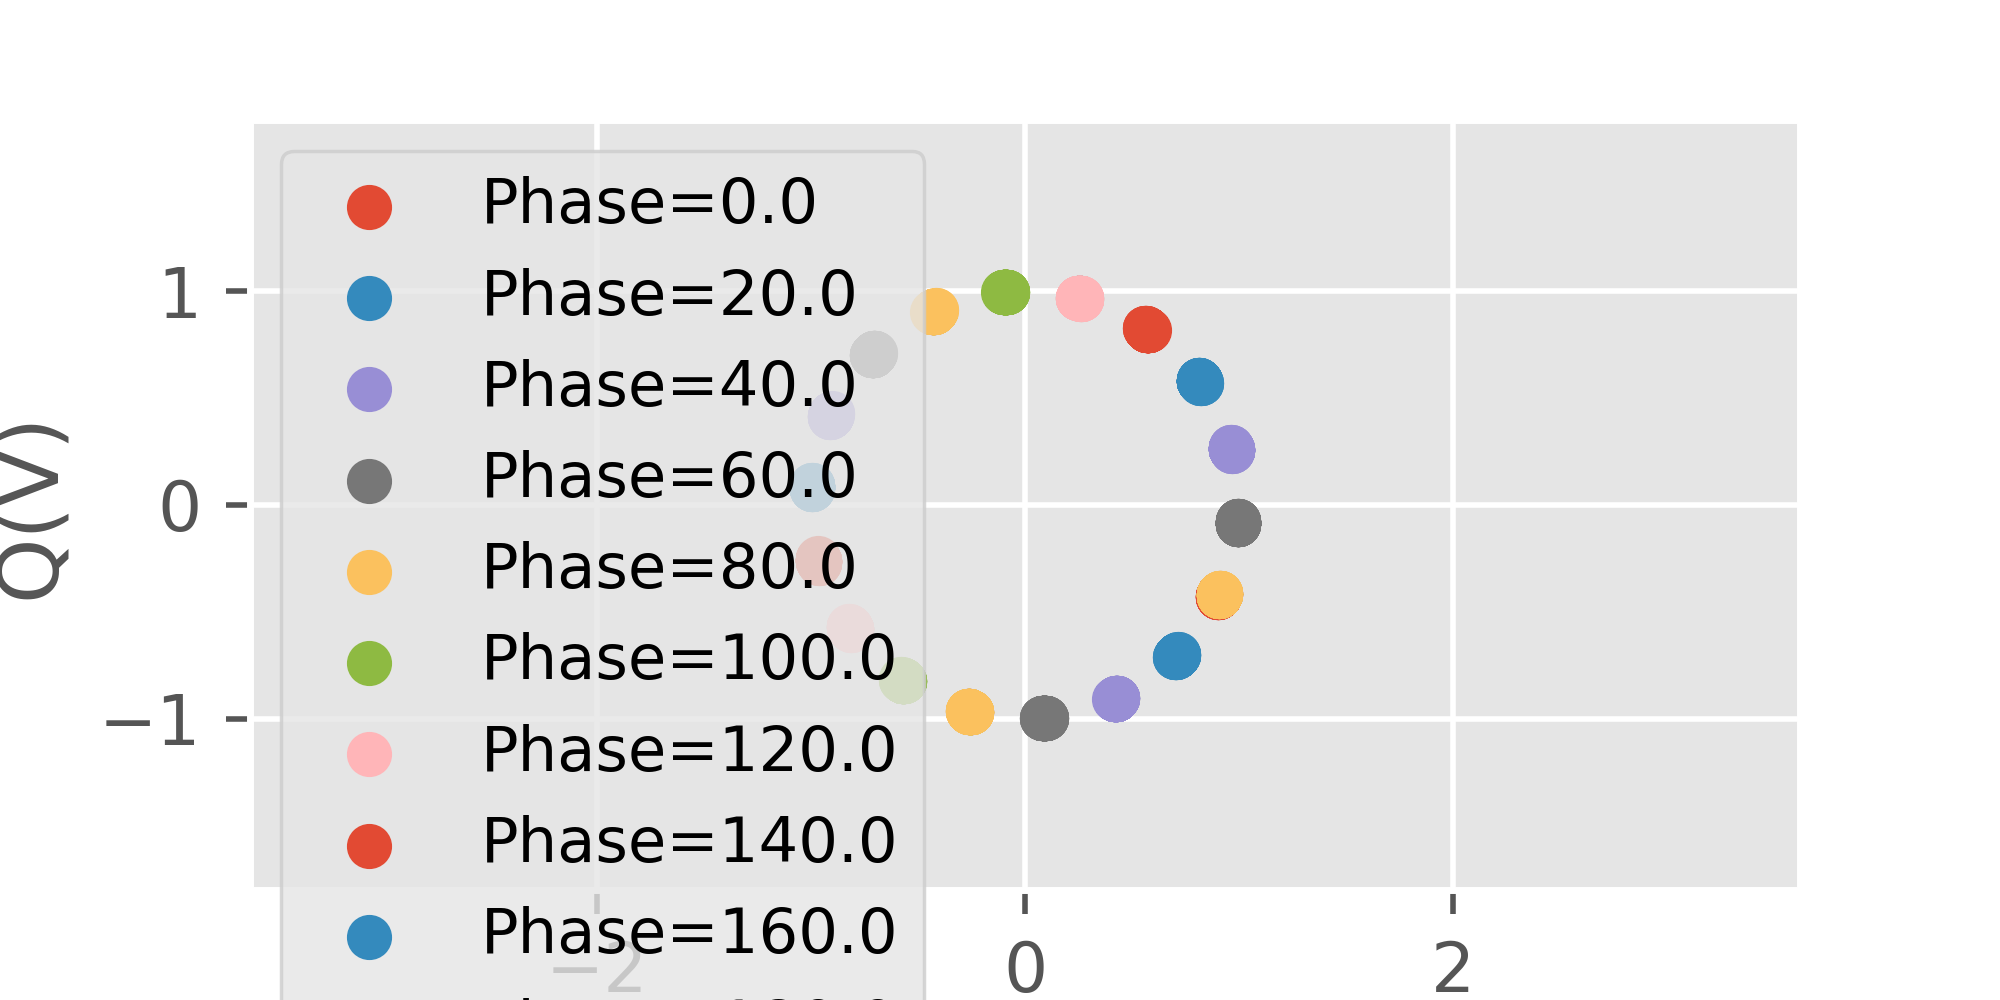

In [83]:
freq = 5.3e9  ## Signal frequency of the OUT channel.
shots = 128
trig_period = 50e-6
rd_out_ch = "S2-O1"
rd_in_ch = "S2-I1"

device.set("Output", 0, "all")
device.set("Output", 1, rd_out_ch)
qsync.set("Shot", shots)
device.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

phase_list = np.linspace(0, 360, 19)
rd_width = 2e-6  ## Sample time width of the IN channel, set it to 2 µs.
rd_delay = 410e-9
wave_width = 4.6e-6
device.set("CaptureMode", 0)
device.set("TimeWidth", rd_width, rd_in_ch)
device.set("TriggerDelay", rd_delay, rd_in_ch)
time_axis = np.linspace(0, wave_width, round(wave_width * da_rate_rd), endpoint=False)

plt.figure(figsize=(10, 5), dpi=500)
for phase_deg in phase_list:
    wave = np.cos(2 * np.pi * freq * time_axis + phase_deg * (np.pi / 180))
    device.set("Waveform", wave, rd_out_ch)  ## Sends the waveforms.
    device.set("FreqList", [float(freq)], rd_in_ch)
    device.set("StartCapture")  ## Notifies the IN channel to start data acquisition.
    qsync.set("GenerateTrig")  ## Generates the trigger signal.
    phi_spectrum = device.get("IQ", rd_in_ch)

    phi_spectrum_norm = np.abs(phi_spectrum)
    phi_spectrum = (phi_spectrum / phi_spectrum_norm).T
    i_data = phi_spectrum.real
    q_data = phi_spectrum.imag

    plt.scatter(i_data, q_data, label=f"Phase={phase_deg}")
    plt.axis("equal")
    plt.ylabel("Q(V)")
    plt.xlabel("I(V)")
    plt.xlim(-5, 5)
    plt.ylim(-1.8, 1.8)
    plt.grid(True)
    plt.legend()

plt.legend(prop={"size": 9}, loc="upper left")
plt.show()


## Experiment Example of the Conventional Control Mode

In [3]:
# ---------- 0. Helper functions for timing alignment ----------
DA_STEP = 16e-9      # DA delay granularity
AD_STEP = 0.25e-9    # AD INDelay granularity

def set_da_pulse(device, ch, wave, start_time, da_rate):
    """
    Set a DA pulse with sub-16-ns timing control.

    The DA channel Delay can only be set in 16 ns steps. Therefore, the
    desired pulse start time is split into:
        1. a coarse delay, written to the channel Delay;
        2. a fine delay, implemented by padding zeros before the waveform.
    """
    coarse_delay = np.floor(start_time / DA_STEP) * DA_STEP
    fine_delay = start_time - coarse_delay
    zero_points = round(fine_delay * da_rate)

    wave_with_delay = np.r_[np.zeros(zero_points), wave]

    device.set("Delay", coarse_delay, ch)
    device.set("Waveform", wave_with_delay, ch)

### S21

Experiments Introduction  
The S21 experiment is used to sweep the resonant frequency of a readout cavity in a superconducting quantum system. This example demonstrates how to use NSQDriver with a PowerQuantum device in conventional control mode to play a probe signal, demodulate the returned signal, and obtain the cavity transmission response.

Experiment Steps
The following steps demonstrate how to perform a cavity resonant frequency sweep using the readout OUT and IN channels controlled through MCI and QSYNC drivers:
1. Initialize the system.
   i. Import dependencies.  
   ii. Configure device address.  
   iii. Configure sample rate for each channel.  
   iv. Configure system parameters.  
   v. Instantiate the MCI and QSYNC drivers and synchronize the system.  
2. Define the probe output channel, probe input channel, frequency sweep range, pulse width, amplitude, shots, trigger period, and timing parameters.
3. Configure the output, capture mode, capture time width, trigger period, and input delay.
4. Generate the probe waveform at each sweep frequency and upload it to the readout output channel.
5. Configure the demodulation frequency list for the readout input channel.
6. Start capture, generate the trigger, and acquire the demodulated IQ data.
7. Average the IQ data, calculate the S21 amplitude in dB, and plot the cavity transmission curve.

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw
%matplotlib widget

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
device_ip = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   2,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(device_ip, 40)
qsync  = QSYNCDriver(device_ip)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 14.0
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


S21 sweep:   0%|          | 0/101 [00:00<?, ?it/s]

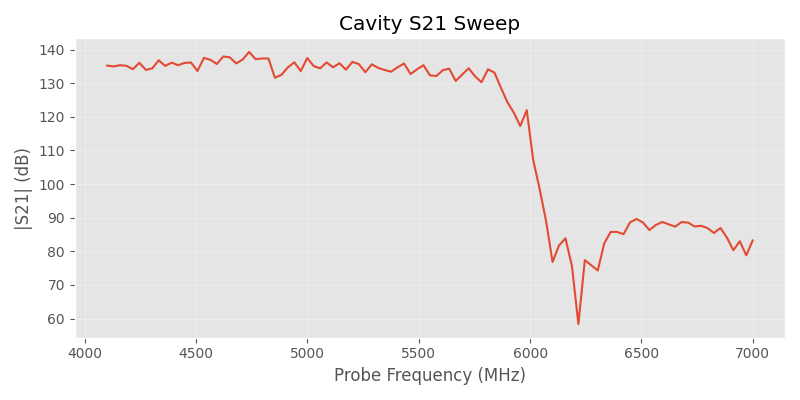

In [9]:
# ---------- 1. Channel and sweep parameters ----------
probe_out_ch    = "S2-O1"                       # probe pulse output channel
probe_in_ch     = "S2-I1"                       # probe signal capture channel

probe_freq_list = np.linspace(4.1e9, 7e9, 101)  # sweep frequency list (Hz)
probe_width     = 2e-6                          # probe pulse duration (s)
probe_amp       = 1.0                           # probe pulse amplitude (normalized)

shots           = 1024                          # averages per frequency point
trig_period     = 100e-6                        # qsync trigger period (s)

probe_out_start = 0                             # probe pulse output start time (s)
probe_in_start  = 200e-9                             # probe signal capture start time (s)

# ---------- 2. Static device configuration ----------
device.set("Output",0, "all")
device.set("Output", 1, probe_out_ch)
device.set("Shot", shots)                            # number of shots on capture side
device.set("TimeWidth", probe_width, probe_in_ch)    # IN-channel capture time window
device.set("CaptureMode", 0)
qsync.set("Shot", shots)                             # number of shots on trigger side
qsync.set("TrigPeriod", trig_period)                 # trigger period


# AD INDelay has 0.25 ns granularity, so it can be set directly.
probe_in_delay = round(probe_in_start / AD_STEP) * AD_STEP
device.set("INDelay", probe_in_delay, probe_in_ch)   # IN-channel input delay

# Prepare a fixed time axis for the probe waveform.
probe_time = np.linspace(
    0,
    probe_width,
    round(probe_width * da_rate_rd),
    endpoint=False,
)

# ---------- 3. Frequency sweep capture ----------
s21_iq_list = []

for probe_freq in tqdm(probe_freq_list, desc="S21 sweep"):

    # Probe output waveform at the current sweep frequency
    probe_wave = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time)

    set_da_pulse(
        device,
        probe_out_ch,
        probe_wave,
        probe_out_start,
        da_rate_rd,
    )                                                        # download probe waveform

    device.set("FreqList", [float(probe_freq)], probe_in_ch)  # configure demodulation frequency
    device.set("StartCapture")                                # start capture
    qsync.set("GenerateTrig")                                 # fire trigger

    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    s21_iq_list.append(iq_data)

# ---------- 4. Data processing and plotting ----------
s21_complex = np.array(s21_iq_list).mean(axis=1)               # average over the shot dimension
s21_power_db = 20 * np.log10(np.abs(s21_complex))              # amplitude to dB

plt.figure(figsize=(8, 4))
plt.plot(probe_freq_list / 1e6, s21_power_db)
plt.xlabel("Probe Frequency (MHz)")
plt.ylabel("|S21| (dB)")
plt.title("Cavity S21 Sweep")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(-4.0, 4.0)

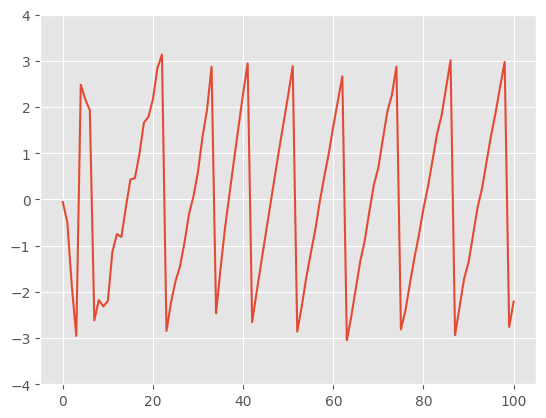

In [259]:
# Because there is a fixed delay, the phase changes with frequency. 
# To correct it, an electrical delay correction can be used.
plt.figure()
rabi_phis = np.angle(s21_complex)
plt.plot(rabi_phis)
plt.ylim([-4,4])

### S21 vs Power

Experiments Introduction  
The S21 vs Power experiment is used to measure the cavity transmission response under different readout powers in a superconducting quantum system. This example helps evaluate the readout cavity response, dynamic range, and power-dependent behavior by sweeping both probe frequency and probe amplitude.

Experiment Steps  
The following steps demonstrate how to perform a two-dimensional S21 sweep versus readout power in conventional control mode:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the probe output channel, probe input channel, probe frequency list, probe power list, pulse width, shots, trigger period, and timing parameters.
3. Configure output enable, capture mode, capture time width, trigger period, and input delay.
4. For each probe power, scale the readout waveform amplitude.
5. For each probe frequency, generate and upload the probe waveform to the readout output channel.
6. Configure the demodulation frequency list for the readout input channel.
7. Start capture, generate the trigger, and acquire demodulated IQ data.
8. Average the IQ data, convert the response to dB, and plot the S21 map versus frequency and readout power.

In [28]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
device_ip = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(device_ip, 40)
qsync  = QSYNCDriver(device_ip)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.5-10-gbf39023
ad_num: 4
da_num: 20
cpu_temp: nan
memory_use: 11.7
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.203开启成功
System synchronization succeeded


In [29]:
# ---------- 1. Channel and sweep parameters ----------
probe_out_ch     = "S2-O1"                       # probe pulse output channel
probe_in_ch      = "S2-I1"                       # probe signal capture channel

probe_freq_list  = np.linspace(4.1e9, 6e9, 51)   # sweep frequency list (Hz)
probe_power_list = np.linspace(0.1, 1, 21)         # probe amplitude sweep list

probe_width      = 2e-6                          # probe pulse duration (s)
probe_amp        = 1.0                           # maximum probe pulse amplitude (normalized)

shots            = 64                            # averages per frequency point
trig_period      = 100e-6                        # qsync trigger period (s)

probe_out_start  = 0                             # probe pulse output start time (s)
probe_in_start   = 0                             # probe signal capture start time (s)

# ---------- 2. Static device configuration ----------
device.set("Output",0, "all")
device.set("Output", 1, probe_out_ch)
device.set("Shot", shots)                            # number of shots on capture side
device.set("TimeWidth", probe_width, probe_in_ch)    # IN-channel capture time window

qsync.set("Shot", shots)                             # number of shots on trigger side
qsync.set("TrigPeriod", trig_period)                 # trigger period

# AD INDelay has 0.25 ns granularity, so it can be set directly.
probe_in_delay = round(probe_in_start / AD_STEP) * AD_STEP
device.set("INDelay", probe_in_delay, probe_in_ch)   # IN-channel input delay

# Prepare a fixed time axis for the probe waveform.
probe_time = np.linspace(
    0,
    probe_width,
    round(probe_width * da_rate_rd),
    endpoint=False,
)

# ---------- 3. Power and frequency sweep capture ----------
s21_iq_power_list = []

for probe_power in tqdm(probe_power_list, desc="Power sweep"):

    s21_iq_list = []

    for probe_freq in probe_freq_list:

        # Probe output waveform at the current amplitude and frequency
        probe_wave = probe_power * probe_amp * np.cos(
            2 * np.pi * probe_freq * probe_time
        )

        set_da_pulse(
            device,
            probe_out_ch,
            probe_wave,
            probe_out_start,
            da_rate_rd,
        )                                                        # download probe waveform

        device.set("FreqList", [float(probe_freq)], probe_in_ch) # configure demodulation frequency
        device.set("StartCapture")                               # start capture
        qsync.set("GenerateTrig")                                # fire trigger

        iq_data = np.asarray(device.get("IQData", probe_in_ch))
        s21_iq_list.append(iq_data)

    s21_iq_power_list.append(s21_iq_list)

# ---------- 4. Data processing and plotting ----------
s21_iq_power_arr = np.array(s21_iq_power_list)                   # (power, freq, shot, n_demod=1)
s21_complex = s21_iq_power_arr.mean(axis=2).squeeze(-1)          # -> (power, freq)
s21_power_db = 20 * np.log10(np.abs(s21_complex))                # amplitude to dB

plt.figure(figsize=(8, 5))
plt.pcolormesh(
    probe_freq_list / 1e6,
    probe_power_list,
    s21_power_db,
    shading="auto",
    cmap="viridis",
)
plt.colorbar(label="|S21| (dB)")
plt.xlabel("Probe Frequency (MHz)")
plt.ylabel("Probe Amplitude (a.u.)")
plt.title("Cavity S21 vs Probe Power")
plt.tight_layout()
plt.show()

Power sweep:   0%|          | 0/21 [00:00<?, ?it/s]

KeyboardInterrupt: 

(-4.0, 4.0)

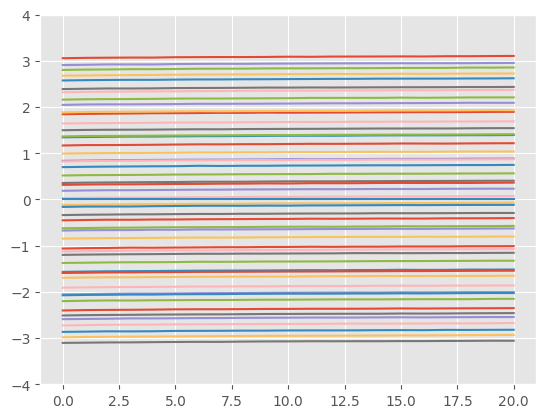

In [262]:
# 滤波器是5.2-7.8GHz，相位图正常
plt.figure()
rabi_phis = np.angle(s21_complex)
plt.plot(rabi_phis)
plt.ylim([-4,4])

### Spectrum

Experiments Introduction  
The Spectrum experiment is used to find the transition frequency of a superconducting qubit. This example sweeps the XY drive frequency while using a fixed readout pulse to measure the qubit-state-dependent cavity response.

Experiment Steps  
The following steps demonstrate how to perform a qubit spectroscopy sweep in conventional control mode:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, readout output channel, readout input channel, XY frequency list, probe frequency, pulse widths, amplitudes, shots, trigger period, and timing offsets.
3. Configure output enable, capture mode, trigger period, demodulation frequency, and readout timing.
4. Prepare the fixed readout waveform and upload it to the readout output channel.
5. For each XY drive frequency, generate and upload the XY drive waveform.
6. Start capture, generate the trigger, and acquire demodulated IQ data from the readout input channel.
7. Average and normalize the IQ data at each frequency point.
8. Plot the spectrum response versus XY drive frequency to identify the qubit transition.

In [30]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
device_ip = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(device_ip, 40)
qsync  = QSYNCDriver(device_ip)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.5-10-gbf39023
ad_num: 4
da_num: 20
cpu_temp: nan
memory_use: 11.7
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.203开启成功
System synchronization succeeded


Spectrum:   0%|          | 0/101 [00:00<?, ?it/s]

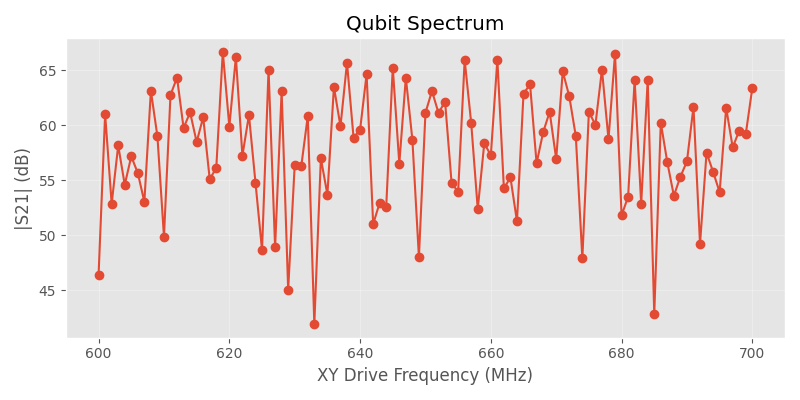

In [32]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch          = "S13-O1"                       # XY drive output channel
probe_out_ch   = "S2-O1"                        # probe pulse output channel
probe_in_ch    = "S2-I1"                        # probe signal capture channel

probe_freq     = 0.3e9                           # probe frequency (Hz)
xy_freq_list   = np.linspace(0.6e9, 0.7e9, 101)   # XY drive frequency sweep list (Hz)

probe_width    = 2e-6                           # probe pulse duration (s)
drive_width    = 2e-6                           # XY drive pulse duration (s)

xy_amp         = 1.0                            # XY drive amplitude (normalized)
probe_amp      = 1.0                            # probe pulse amplitude (normalized)

shots          = 64                             # averages per frequency point
trig_period    = 500e-6                         # qsync trigger period (s)

xy_start        = 0                             # XY drive start time (s)
probe_out_start = drive_width + 200e-9          # probe pulse output start time (s)
probe_in_start  = drive_width + 400e-9          # probe signal capture start time (s)

# ---------- 2. Static device configuration ----------
device.set("Output",0, "all")
device.set("Output", 1, probe_out_ch)
device.set("Output", 1, xy_ch)
device.set("Shot", shots)                            # number of shots on capture side
device.set("TimeWidth", probe_width, probe_in_ch)    # IN-channel capture time window
device.set("FreqList", [float(probe_freq)], probe_in_ch)  # configure demodulation frequency

qsync.set("Shot", shots)                             # number of shots on trigger side
qsync.set("TrigPeriod", trig_period)                 # trigger period

# ---------- 3. Fixed waveform preparation ----------
# Probe output waveform
probe_time = np.linspace(
    0,
    probe_width,
    round(probe_width * da_rate_rd),
    endpoint=False,
)
probe_wave = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time)

set_da_pulse(
    device,
    probe_out_ch,
    probe_wave,
    probe_out_start,
    da_rate_rd,
)                                                        # download probe waveform

# Prepare a fixed time axis for the XY drive waveform.
xy_time = np.linspace(
    0,
    drive_width,
    round(drive_width * da_rate_xy),
    endpoint=False,
)

# AD INDelay has 0.25 ns granularity, so it can be set directly.
probe_in_delay = round(probe_in_start / AD_STEP) * AD_STEP
device.set("INDelay", probe_in_delay, probe_in_ch)       # IN-channel input delay

# ---------- 4. Frequency sweep capture ----------
spectrum_iq_list = []

for xy_freq in tqdm(xy_freq_list, desc="Spectrum"):

    # XY drive waveform at the current sweep frequency
    xy_wave = xy_amp * np.cos(2 * np.pi * xy_freq * xy_time)

    set_da_pulse(
        device,
        xy_ch,
        xy_wave,
        xy_start,
        da_rate_xy,
    )                                                    # download XY drive waveform

    device.set("StartCapture")                          # start capture
    qsync.set("GenerateTrig")                           # fire trigger

    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    spectrum_iq_list.append(iq_data)

# ---------- 5. Data processing and plotting ----------
spectrum_complex = np.array(spectrum_iq_list).mean(axis=1)  # average over the shot dimension
spectrum_db = 20 * np.log10(np.abs(spectrum_complex))       # amplitude to dB

plt.figure(figsize=(8, 4))
plt.plot(xy_freq_list / 1e6, spectrum_db, marker="o")
plt.xlabel("XY Drive Frequency (MHz)")
plt.ylabel("|S21| (dB)")
plt.title("Qubit Spectrum")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(-4.0, 4.0)

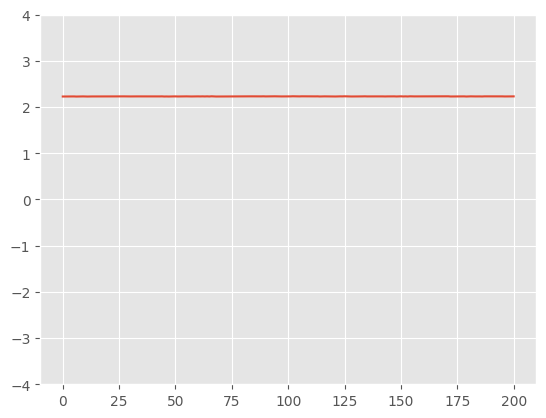

In [267]:
# 固定频率，相位不变
plt.figure()
rabi_phis = np.angle(spectrum_complex)
plt.plot(rabi_phis)
plt.ylim([-4,4])
# plt.show()


### Spectrum vs Flux

Experiments Introduction  
The Spectrum vs Flux experiment is used to measure how the transition frequency of a superconducting qubit changes with flux bias. This example sweeps the XY drive frequency while stepping the Z bias amplitude, producing a two-dimensional qubit spectrum map.

Experiment Steps  
The following steps demonstrate how to perform a qubit spectroscopy measurement versus flux bias in conventional control mode:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, XY frequency list, bias list, pulse widths, amplitudes, and timing offsets.
3. Configure output enable, capture mode, trigger period, demodulation frequency, and readout timing.
4. Prepare the fixed readout waveform and upload it to the readout output channel.
5. For each flux-bias point, generate and upload the Z bias waveform.
6. For each XY frequency, generate the XY drive waveform and play it before readout.
7. Start capture, generate the trigger, and acquire demodulated IQ data.
8. Average and normalize the IQ data, then plot the qubit spectrum as a function of XY frequency and flux bias.

In [33]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
device_ip = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(device_ip, 40)
qsync  = QSYNCDriver(device_ip)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.5-10-gbf39023
ad_num: 4
da_num: 20
cpu_temp: nan
memory_use: 11.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.203开启成功
System synchronization succeeded


Flux sweep:   0%|          | 0/20 [00:00<?, ?it/s]

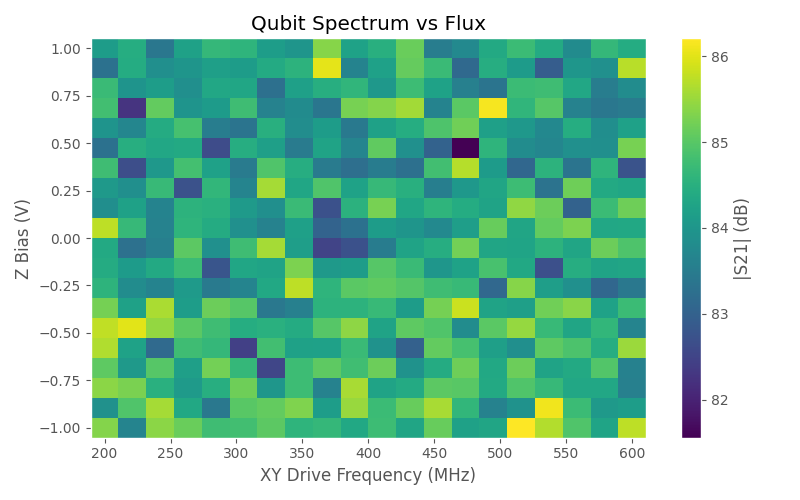

In [35]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch          = "S13-O1"                       # XY drive output channel
z_ch           = "S12-O1"                       # Z bias output channel
probe_out_ch   = "S2-O1"                        # probe pulse output channel
probe_in_ch    = "S2-I1"                        # probe signal capture channel

probe_freq     = 0.5e9                          # probe frequency (Hz)
xy_freq_list   = np.linspace(0.2e9, 0.6e9, 20)    # XY drive frequency sweep list (Hz)
bias_list      = np.linspace(-1, 1, 20)         # Z bias sweep list (V)

probe_width    = 1e-6                           # probe pulse duration (s)
drive_width    = 1e-6                           # XY drive pulse duration (s)

xy_amp         = 1.0                            # XY drive amplitude (normalized)
probe_amp      = 1.0                            # probe pulse amplitude (normalized)

shots          = 64                             # averages per frequency point
trig_period    = 500e-6                         # qsync trigger period (s)

# Timing margins and readout offsets
z_margin       = 96e-9                          # Z margin reserved before/after sequence
readout_gap    = 100e-9                         # delay from XY drive end to probe output
capture_gap    = 400e-9                         # delay from probe output to probe capture

# ---------- 2. Static device configuration ----------
device.set("Output",0, "all")
device.set("Output", 1, probe_out_ch)
device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Shot", shots)                            # number of shots on capture side
device.set("TimeWidth", probe_width, probe_in_ch)    # IN-channel capture time window
device.set("FreqList", [float(probe_freq)], probe_in_ch)  # configure demodulation frequency
device.set("CaptureMode", 0)                         # Capture mode

qsync.set("Shot", shots)                             # number of shots on trigger side
qsync.set("TrigPeriod", trig_period)                 # trigger period

# Define all pulse timings on a common time axis.
z_start = 0
xy_start = z_margin
xy_end = xy_start + drive_width

# Readout starts after the XY pulse, not after Z pulse end.
probe_out_start = xy_end + readout_gap
probe_in_start = probe_out_start + capture_gap

# Z bias covers XY pulse, readout pulse, capture window, and final margin.
z_width = probe_in_start + probe_width + z_margin

# ---------- 3. Fixed waveform preparation ----------
# Probe output waveform
probe_time = np.linspace(
    0,
    probe_width,
    round(probe_width * da_rate_rd),
    endpoint=False,
)
probe_wave = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time)

set_da_pulse(
    device,
    probe_out_ch,
    probe_wave,
    probe_out_start,
    da_rate_rd,
)                                                        # download probe waveform

# Prepare a fixed time axis for the XY drive waveform.
xy_time = np.linspace(
    0,
    drive_width,
    round(drive_width * da_rate_xy),
    endpoint=False,
)

# AD INDelay has 0.25 ns granularity, so it can be set directly.
probe_in_delay = round(probe_in_start / AD_STEP) * AD_STEP
device.set("INDelay", probe_in_delay, probe_in_ch)       # IN-channel input delay

# ---------- 4. 2D sweep capture ----------
spectrum_2d = []

for bias in tqdm(bias_list, desc="Flux sweep"):

    # Z bias waveform at the current flux-bias point.
    # It covers XY pulse, readout pulse, capture window, and final margin.
    z_wave = bias * np.ones(round(z_width * da_rate_z))
    z_wave[-1] = 0

    set_da_pulse(
        device,
        z_ch,
        z_wave,
        z_start,
        da_rate_z,
    )                                                     # download Z bias waveform

    spectrum_row = []

    for xy_freq in xy_freq_list:

        # XY drive waveform at the current sweep frequency
        xy_wave = xy_amp * np.cos(2 * np.pi * xy_freq * xy_time)

        set_da_pulse(
            device,
            xy_ch,
            xy_wave,
            xy_start,
            da_rate_xy,
        )                                                 # download XY drive waveform

        device.set("StartCapture")                       # start capture
        qsync.set("GenerateTrig")                        # fire trigger

        iq_data = np.asarray(device.get("IQData", probe_in_ch))
        spectrum_row.append(iq_data)

    spectrum_2d.append(spectrum_row)

# ---------- 5. Data processing and plotting ----------
spectrum_2d_arr = np.array(spectrum_2d)                  # (bias, freq, shot, n_demod=1)
spectrum_2d_complex = spectrum_2d_arr.mean(axis=2).squeeze(-1)  # -> (bias, freq)
spectrum_2d_db = 20 * np.log10(np.abs(spectrum_2d_complex))     # amplitude to dB

plt.figure(figsize=(8, 5))
plt.pcolormesh(
    xy_freq_list / 1e6,
    bias_list,
    spectrum_2d_db,
    shading="auto",
    cmap="viridis",
)
plt.colorbar(label="|S21| (dB)")
plt.xlabel("XY Drive Frequency (MHz)")
plt.ylabel("Z Bias (V)")
plt.title("Qubit Spectrum vs Flux")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
rabi_phis = np.angle(spectrum_2d_complex)
plt.plot(rabi_phis)
plt.ylim([-4,4])

### Power Rabi

Experiments Introduction  
The Power Rabi experiment is used to calibrate the pulse amplitude required to rotate a superconducting qubit by a desired angle. This example sweeps the XY drive amplitude while keeping the pulse duration and drive frequency fixed, then reads out the qubit response.

Experiment Steps  
The following steps demonstrate how to perform a Power Rabi measurement in conventional control mode:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, amplitude list, drive frequency, pulse width, and readout parameters.
3. Configure output enable, capture mode, trigger period, demodulation frequency, and readout timing.
4. Prepare the fixed readout waveform and upload it to the readout output channel.
5. For each drive amplitude, generate the XY drive waveform with the specified amplitude.
6. Align the XY drive, Z bias, readout pulse, and capture window in time.
7. Start capture, generate the trigger, and acquire demodulated IQ data.
8. Plot the qubit response versus drive amplitude and determine the pi-pulse and half-pi-pulse amplitudes.

In [36]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
device_ip = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(device_ip, 40)
qsync  = QSYNCDriver(device_ip)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.5-10-gbf39023
ad_num: 4
da_num: 20
cpu_temp: nan
memory_use: 11.8
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.203开启成功
System synchronization succeeded


Power Rabi:   0%|          | 0/101 [00:00<?, ?it/s]

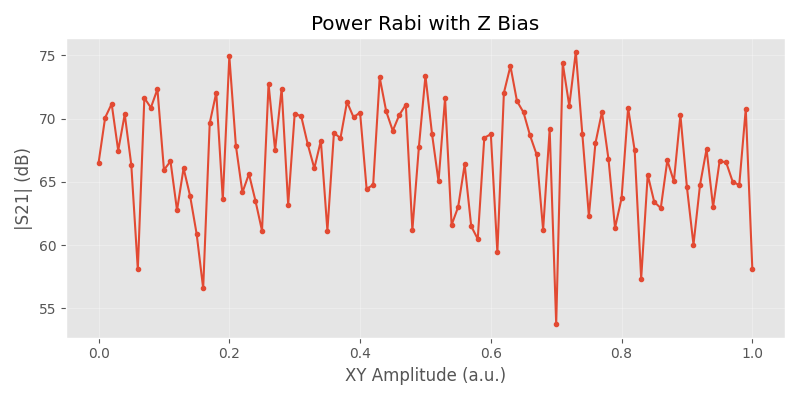

In [37]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch         = "S13-O1"
z_ch          = "S12-O1"
probe_out_ch  = "S2-O1"
probe_in_ch   = "S2-I1"

probe_freq    = 0.6e9
xy_freq       = 0.4e9

probe_width   = 1e-6
drive_width   = 1e-6

probe_amp     = 1.0
bias          = 1.0

shots         = 64
trig_period   = 500e-6

# XY amplitude sweep
xy_amp_list   = np.linspace(0, 1, 101)

# Timing margins and readout offsets
z_margin      = 96e-9
readout_gap   = 100e-9
capture_gap   = 400e-9

# ---------- 2. Static device configuration ----------
device.set("Output",0, "all")
device.set("Output", 1, probe_out_ch)
device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Shot", shots)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)

qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

# Define all pulse timings on a common time axis.
z_start = 0
xy_start = z_margin
xy_end = xy_start + drive_width

# Readout starts after the XY pulse.
probe_out_start = xy_end + readout_gap
probe_in_start = probe_out_start + capture_gap

# Z bias covers XY pulse, readout pulse, capture window, and final margin.
z_width = probe_in_start + probe_width + z_margin

# ---------- 3. Fixed waveform preparation ----------
# Probe output waveform
probe_time = np.linspace(
    0,
    probe_width,
    round(probe_width * da_rate_rd),
    endpoint=False,
)
probe_wave = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time)

set_da_pulse(device, probe_out_ch, probe_wave, probe_out_start, da_rate_rd)

# Fixed Z bias waveform
z_wave = bias * np.ones(round(z_width * da_rate_z))
z_wave[-1] = 0

set_da_pulse(device, z_ch, z_wave, z_start, da_rate_z)

# XY drive waveform without amplitude scaling.
# The amplitude is updated inside the sweep loop.
xy_time = np.linspace(
    0,
    drive_width,
    round(drive_width * da_rate_xy),
    endpoint=False,
)
xy_wave_base = np.cos(2 * np.pi * xy_freq * xy_time)

# AD INDelay has 0.25 ns granularity, so it can be set directly.
probe_in_delay = round(probe_in_start / AD_STEP) * AD_STEP
device.set("INDelay", probe_in_delay, probe_in_ch)

# ---------- 4. Amplitude sweep capture ----------
rabi_iq_list = []

for xy_amp in tqdm(xy_amp_list, desc="Power Rabi"):

    # XY drive waveform with swept amplitude
    xy_wave = xy_amp * xy_wave_base
    set_da_pulse(device, xy_ch, xy_wave, xy_start, da_rate_xy)

    device.set("StartCapture")
    qsync.set("GenerateTrig")

    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    rabi_iq_list.append(iq_data)

# ---------- 5. Data processing and plotting ----------
rabi_complex = np.array(rabi_iq_list).mean(axis=1)
rabi_db = 20 * np.log10(np.abs(rabi_complex))

plt.figure(figsize=(8, 4))
plt.plot(xy_amp_list, rabi_db, marker="o", markersize=3)
plt.xlabel("XY Amplitude (a.u.)")
plt.ylabel("|S21| (dB)")
plt.title("Power Rabi with Z Bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(1)
rabi_phis = np.angle(rabi_complex)
plt.plot(rabi_phis)
plt.ylim([-4,4])
plt.show()

### Time Rabi

Experiments Introduction  
The Time Rabi experiment is used to calibrate the pulse duration required to rotate a superconducting qubit by a desired angle. This example sweeps the XY drive pulse width while keeping the drive amplitude and frequency fixed, then reads out the qubit response.

Experiment Steps  
The following steps demonstrate how to perform a Time Rabi measurement in conventional control mode:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, pulse width list, drive frequency, drive amplitude, and readout parameters.
3. Configure output enable, capture mode, trigger period, demodulation frequency, and readout timing.
4. Prepare the fixed readout waveform and upload it to the readout output channel.
5. For each pulse width, generate the XY drive waveform with the specified duration.
6. Align the XY drive, Z bias, readout pulse, and capture window in time.
7. Start capture, generate the trigger, and acquire demodulated IQ data.
8. Plot the qubit response versus pulse width and determine the pi-pulse and half-pi-pulse durations.

In [41]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
device_ip = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(device_ip, 40)
qsync  = QSYNCDriver(device_ip)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.5-10-gbf39023
ad_num: 4
da_num: 20
cpu_temp: nan
memory_use: 11.7
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.203开启成功
System synchronization succeeded


Time Rabi:   0%|          | 0/62 [00:00<?, ?it/s]

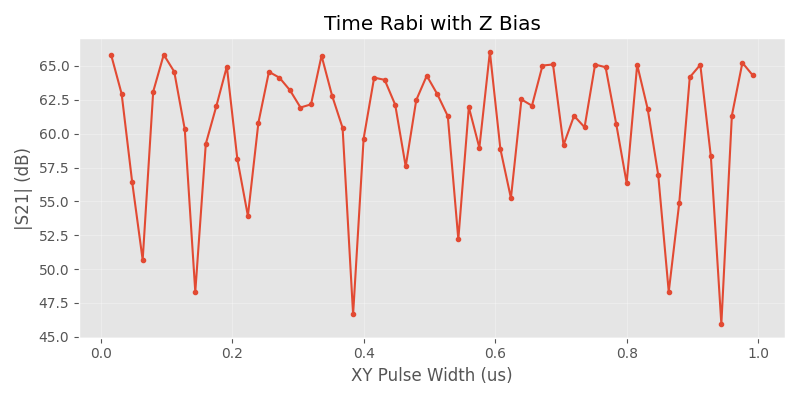

In [42]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch         = "S13-O1"
z_ch          = "S12-O1"
probe_out_ch  = "S2-O1"
probe_in_ch   = "S2-I1"

probe_freq    = 0.3e9
xy_freq       = 0.3e9

probe_width   = 1e-6

probe_amp     = 1.0
xy_amp        = 1.0
bias          = 1.0

shots         = 1024
trig_period   = 500e-6

# XY pulse width sweep
drive_width_list = np.linspace(16e-9, 1e-6, 101)
drive_width_list = np.unique(np.round(drive_width_list / DA_STEP) * DA_STEP)

# Timing margins and readout offsets
z_margin      = 96e-9
readout_gap   = 100e-9
capture_gap   = 400e-9

# ---------- 2. Static device configuration ----------
device.set("Output",0, "all")
device.set("Output", 1, probe_out_ch)
device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Shot", shots)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)

qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

# ---------- 3. Fixed waveform preparation ----------
# Probe output waveform
probe_time = np.linspace(
    0,
    probe_width,
    round(probe_width * da_rate_rd),
    endpoint=False,
)
probe_wave = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time)

# ---------- 4. Width sweep capture ----------
rabi_iq_list = []

for drive_width in tqdm(drive_width_list, desc="Time Rabi"):

    # Define all pulse timings on a common time axis.
    z_start = 0
    xy_start = z_margin
    xy_end = xy_start + drive_width

    # Readout starts after the current XY pulse.
    probe_out_start = xy_end + readout_gap
    probe_in_start = probe_out_start + capture_gap

    # Z bias covers XY pulse, readout pulse, capture window, and final margin.
    z_width = probe_in_start + probe_width + z_margin

    # XY drive waveform with swept pulse width
    xy_time = np.linspace(
        0,
        drive_width,
        round(drive_width * da_rate_xy),
        endpoint=False,
    )
    xy_wave = xy_amp * np.cos(2 * np.pi * xy_freq * xy_time)

    set_da_pulse(device, xy_ch, xy_wave, xy_start, da_rate_xy)

    # Z bias waveform for the current pulse width
    z_wave = bias * np.ones(round(z_width * da_rate_z))
    z_wave[-1] = 0
    set_da_pulse(device, z_ch, z_wave, z_start, da_rate_z)

    # Probe output waveform
    set_da_pulse(device, probe_out_ch, probe_wave, probe_out_start, da_rate_rd)

    # AD INDelay has 0.25 ns granularity, so it can be set directly.
    probe_in_delay = round(probe_in_start / AD_STEP) * AD_STEP
    device.set("INDelay", probe_in_delay, probe_in_ch)

    device.set("StartCapture")
    qsync.set("GenerateTrig")

    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    rabi_iq_list.append(iq_data)

# ---------- 5. Data processing and plotting ----------
rabi_complex = np.array(rabi_iq_list).mean(axis=1)
rabi_db = 20 * np.log10(np.abs(rabi_complex))

plt.figure(figsize=(8, 4))
plt.plot(drive_width_list * 1e6, rabi_db, marker="o", markersize=3)
plt.xlabel("XY Pulse Width (us)")
plt.ylabel("|S21| (dB)")
plt.title("Time Rabi with Z Bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(-3.0, 3.0)

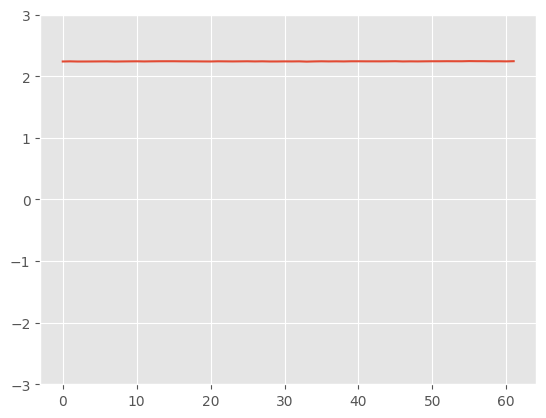

In [299]:
plt.figure()
rabi_phis = np.angle(rabi_complex)
plt.plot(rabi_phis)
plt.ylim([-4,4])

### T1

Experiments Introduction  
The T1 experiment is used to measure the energy relaxation time of a superconducting qubit. This example demonstrates how to excite the qubit with a pi pulse, wait for a variable delay, and then read out the remaining excited-state population.

Experiment Steps  
The following steps demonstrate how to perform a T1 relaxation measurement in conventional control mode:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, relaxation delay list, pulse widths, amplitudes, and timing offsets.
3. Configure output enable, capture mode, trigger period, demodulation frequency, and readout timing.
4. Prepare the fixed readout waveform and upload it to the readout output channel.
5. For each delay, generate the qubit pi pulse, wait for the specified relaxation time, and then perform readout.
6. Align the XY drive, Z bias, readout pulse, and capture window in time.
7. Start capture, generate the trigger, and acquire demodulated IQ data.
8. Plot the measured response versus delay and fit the decay curve to extract the T1 time.

In [43]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
device_ip = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(device_ip, 40)
qsync  = QSYNCDriver(device_ip)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.5-10-gbf39023
ad_num: 4
da_num: 20
cpu_temp: nan
memory_use: 11.8
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.203开启成功
System synchronization succeeded


T1:   0%|          | 0/100 [00:00<?, ?it/s]

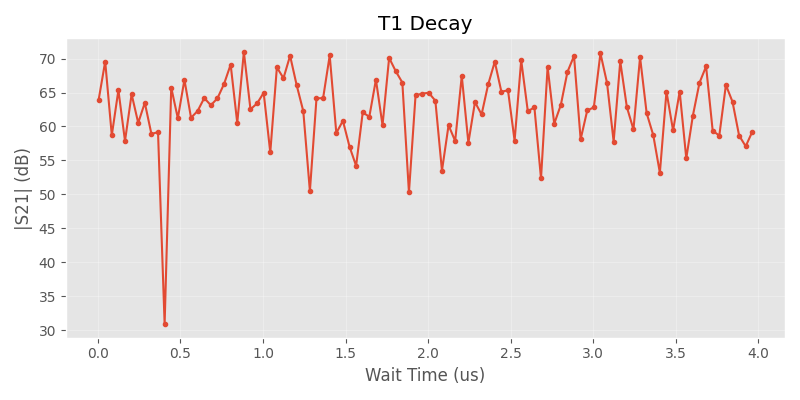

In [44]:
# ---------- 2. Channel and sweep parameters ----------
xy_ch          = "S13-O1"                       # XY drive output channel
z_ch           = "S12-O1"                       # Z bias output channel
probe_out_ch   = "S2-O1"                        # probe pulse output channel
probe_in_ch    = "S2-I1"                        # probe signal capture channel

probe_freq     = 0.3e9                          # probe frequency (Hz)
xy_freq        = 0.3e9                          # XY drive frequency (Hz)

probe_width    = 1e-6                           # probe pulse duration (s)
drive_width    = 0.2e-6                         # pi pulse duration (s)

xy_amp         = 1.0                            # XY drive amplitude
probe_amp      = 1.0                            # probe pulse amplitude
bias           = 1.0                            # Z bias amplitude

shots          = 64                             # averages per wait-time point
trig_period    = 500e-6                         # qsync trigger period (s)

wait_time_list = np.arange(4e-9, 4e-9 * 1000, 40e-9)

# Timing margins and readout offsets
z_margin       = 96e-9                          # Z margin before/after sequence
readout_gap    = 0                              # delay after pi pulse
capture_gap    = 400e-9                         # delay from probe output to capture

# Define pulse timings on a common time axis.
z_start = 0
xy_start = z_margin
drive_end = xy_start + drive_width

# Minimal-change fix:
# Use the longest T1 delay to make one Z pulse cover all sweep points.
max_wait_time = np.max(wait_time_list)
max_probe_out_start = drive_end + readout_gap + max_wait_time
max_probe_in_start = max_probe_out_start + capture_gap
z_width = max_probe_in_start + probe_width + z_margin


# ---------- 3. Static device configuration ----------
device.set("Output",0, "all")
device.set("Output", 1, probe_out_ch)
device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Shot", shots)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)

qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)


# ---------- 4. Fixed waveform preparation ----------
# Pi pulse waveform
xy_time = np.linspace(
    0,
    drive_width,
    round(drive_width * da_rate_xy),
    endpoint=False,
)
xy_wave = xy_amp * np.cos(2 * np.pi * xy_freq * xy_time)

set_da_pulse(
    device,
    xy_ch,
    xy_wave,
    xy_start,
    da_rate_xy,
)

# Z bias waveform
# The Z pulse now covers pi pulse, max T1 delay, readout, capture, and final margin.
z_wave = bias * np.ones(round(z_width * da_rate_z))
z_wave[-1] = 0

set_da_pulse(
    device,
    z_ch,
    z_wave,
    z_start,
    da_rate_z,
)

# Probe output waveform
probe_time = np.linspace(
    0,
    probe_width,
    round(probe_width * da_rate_rd),
    endpoint=False,
)
probe_wave = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time)


# ---------- 5. Wait-time sweep capture ----------
t1_iq_list = []

for wait_time in tqdm(wait_time_list, desc="T1"):

    # The probe pulse starts after the pi pulse and the swept T1 delay.
    probe_out_start = drive_end + readout_gap + wait_time
    probe_in_start = probe_out_start + capture_gap

    set_da_pulse(
        device,
        probe_out_ch,
        probe_wave,
        probe_out_start,
        da_rate_rd,
    )

    # AD INDelay has 0.25 ns granularity, so it can be set directly.
    probe_in_delay = round(probe_in_start / AD_STEP) * AD_STEP
    device.set("INDelay", probe_in_delay, probe_in_ch)

    device.set("StartCapture")
    qsync.set("GenerateTrig")

    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    t1_iq_list.append(iq_data)


# ---------- 6. Data processing and plotting ----------
t1_complex = np.array(t1_iq_list).mean(axis=1)
t1_db = 20 * np.log10(np.abs(t1_complex))

plt.figure(figsize=(8, 4))
plt.plot(wait_time_list * 1e6, t1_db, marker="o", markersize=3)
plt.xlabel("Wait Time (us)")
plt.ylabel("|S21| (dB)")
plt.title("T1 Decay")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

time.sleep(1)

(-3.0, 3.0)

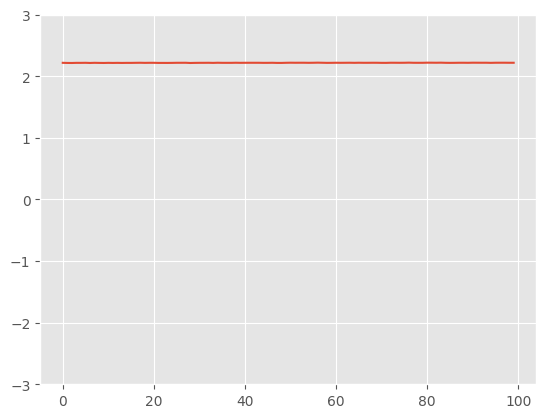

In [305]:
plt.figure()
rabi_phis = np.angle(t1_complex)
plt.plot(rabi_phis)
plt.ylim([-3,3])

### T2

Experiments Introduction  
The T2 experiment is used to measure the dephasing time of a superconducting qubit. This example demonstrates how to apply two half-pi pulses separated by a variable Ramsey delay, followed by readout of the qubit state.

Experiment Steps  
The following steps demonstrate how to perform a Ramsey T2 measurement in conventional control mode:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, Ramsey delay list, pulse widths, amplitudes, and timing offsets.
3. Configure output enable, capture mode, trigger period, demodulation frequency, and readout timing.
4. Prepare the fixed readout waveform and upload it to the readout output channel.
5. For each Ramsey delay, generate the two half-pi XY pulses with the specified separation.
6. Align the XY drive, Z bias, readout pulse, and capture window in time.
7. Start capture, generate the trigger, and acquire demodulated IQ data.
8. Plot the Ramsey oscillation or envelope versus delay and extract the qubit dephasing time.

In [45]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
device_ip = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(device_ip, 40)
qsync  = QSYNCDriver(device_ip)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.5-10-gbf39023
ad_num: 4
da_num: 20
cpu_temp: nan
memory_use: 11.7
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.203开启成功
System synchronization succeeded


T2 Ramsey:   0%|          | 0/126 [00:00<?, ?it/s]

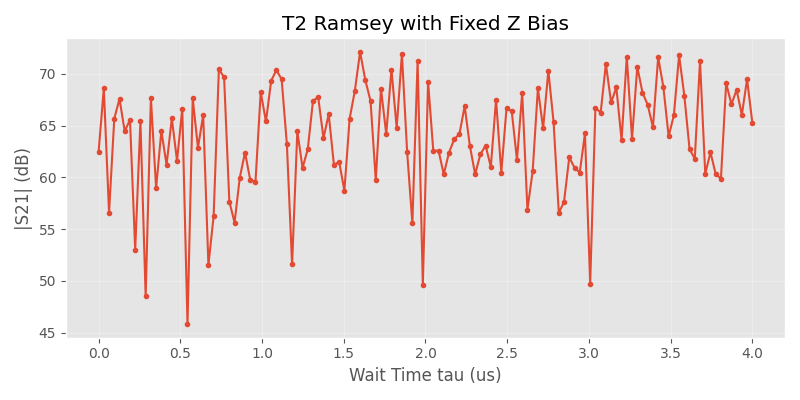

In [46]:
# ---------- 2. Channel and sweep parameters ----------
xy_ch          = "S13-O1"
z_ch           = "S12-O1"
probe_out_ch   = "S2-O1"
probe_in_ch    = "S2-I1"

detuning_freq  = 1e6

# If your setup uses low IF plus external LO, change this according to the actual IF.
probe_freq     = 0.3e9
xy_freq        = 0.3e9 + detuning_freq

probe_width    = 1e-6
xy_pulse_width = 0.5e-6

xy_amp         = 1.0
probe_amp      = 1.0

# Fixed Z bias value for the whole T2 Ramsey experiment.
z_bias         = 1.0

shots          = 64
trig_period    = 500e-6

wait_step      = 32e-9
wait_time_list = np.arange(0, 4e-6 + 0.5 * wait_step, wait_step)

# Timing margins and readout offsets
z_margin       = 96e-9
readout_gap    = 100e-9
capture_gap    = 400e-9

z_start = 0
xy_start = z_margin

# Use the longest Ramsey delay to make one fixed Z pulse cover all sweep points.
pulse_samples = round(xy_pulse_width * da_rate_xy)
max_gap_samples = round(np.max(wait_time_list) * da_rate_xy)
max_total_samples = 2 * pulse_samples + max_gap_samples
max_total_xy_width = max_total_samples / da_rate_xy

max_probe_out_start = xy_start + max_total_xy_width + readout_gap
max_probe_in_start = max_probe_out_start + capture_gap
z_width = max_probe_in_start + probe_width + z_margin


# ---------- 3. Static device configuration ----------
device.set("Output",0, "all")
device.set("Output", 1, probe_out_ch)
device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Shot", shots)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)

qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)


# ---------- 4. Fixed waveform preparation ----------
# Fixed Z bias waveform, downloaded once.
z_wave = z_bias * np.ones(round(z_width * da_rate_z))
z_wave[-1] = 0

set_da_pulse(
    device,
    z_ch,
    z_wave,
    z_start,
    da_rate_z,
)

# Probe output waveform
probe_time = np.linspace(
    0,
    probe_width,
    round(probe_width * da_rate_rd),
    endpoint=False,
)
probe_wave = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time)


# ---------- 5. Wait-time sweep capture ----------
t2_iq_list = []

for wait_time in tqdm(wait_time_list, desc="T2 Ramsey"):

    # Ramsey sequence: pi/2 pulse - wait time - pi/2 pulse
    gap_samples = round(wait_time * da_rate_xy)
    total_samples = 2 * pulse_samples + gap_samples
    total_xy_width = total_samples / da_rate_xy

    xy_time = np.linspace(
        0,
        total_xy_width,
        total_samples,
        endpoint=False,
    )

    xy_wave = np.zeros(total_samples)

    # First pi/2 pulse
    xy_wave[:pulse_samples] = xy_amp * np.cos(
        2 * np.pi * xy_freq * xy_time[:pulse_samples]
    )

    # Second pi/2 pulse, using the same continuous time axis.
    second_start = pulse_samples + gap_samples
    xy_wave[second_start:] = xy_amp * np.cos(
        2 * np.pi * xy_freq * xy_time[second_start:]
    )

    set_da_pulse(
        device,
        xy_ch,
        xy_wave,
        xy_start,
        da_rate_xy,
    )

    # Readout starts after the current Ramsey sequence, not after fixed Z end.
    probe_out_start = xy_start + total_xy_width + readout_gap
    probe_in_start = probe_out_start + capture_gap

    set_da_pulse(
        device,
        probe_out_ch,
        probe_wave,
        probe_out_start,
        da_rate_rd,
    )

    probe_in_delay = round(probe_in_start / AD_STEP) * AD_STEP
    device.set("INDelay", probe_in_delay, probe_in_ch)

    device.set("StartCapture")
    qsync.set("GenerateTrig")

    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    t2_iq_list.append(iq_data)


# ---------- 6. Data processing and plotting ----------
t2_complex = np.array(t2_iq_list).mean(axis=1)
t2_db = 20 * np.log10(np.abs(t2_complex))

plt.figure(figsize=(8, 4))
plt.plot(wait_time_list * 1e6, t2_db, marker="o", markersize=3)
plt.xlabel("Wait Time tau (us)")
plt.ylabel("|S21| (dB)")
plt.title("T2 Ramsey with Fixed Z Bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(-3.0, 3.0)

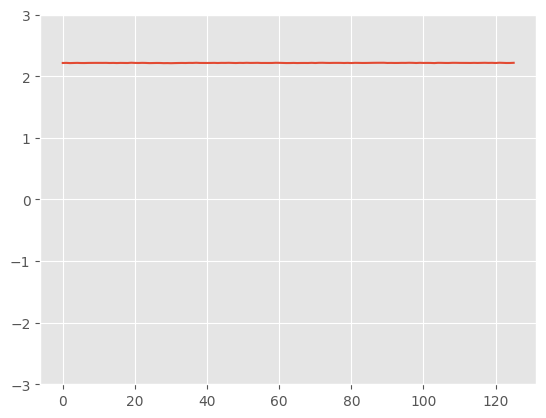

In [310]:
plt.figure()
rabi_phis = np.angle(t2_complex)
plt.plot(rabi_phis)
plt.ylim([-3,3])

# Chapter 5	Programming Examples for Instructions Set Control Mode

## firmware change

In [3]:
# # #PowerQ firmware change
UpdatedeviceIP = "172.16.153.203"
driverUpdate = MCIDriver(UpdatedeviceIP,300)
driverUpdate.open(debug=True)
# "1" means Instruction Set Control Mode, "0" means AWG Mode 
driverUpdate.set('FirmwareChange',[0,1,1,1],["S2-O1","S12-O1","S13-O1", "S3-O1"])

## Test Cases of Instructions Set Control Mode

### To Initialize the System

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-4-g5897ea1
ad_num: 4
da_num: 12
cpu_temp: nan
memory_use: 10.2
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.203开启成功
System synchronization succeeded


### To Play Signal with DDS mode

In [ ]:
@nw.kernel
def program(envelope: np.ndarray):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    wave: np.ndarray = np.ones(int(time_width * srate))
    frame_0: nw.Frame = nw.init_frame(100e6, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_0, 1, 0, 0)
    nw.wait(2e-6)
    nw.play_wave(envelope_0, 0.5, 100e6, 0.5*np.pi)
    return nw.Kernel
_k1 = program()

device.set('ProgramOUT', _k1, f'S13-O1')

ch = "S13-O1"
shots = 0xFFFFFFFF
device.set("Output", 0, "all")
device.set("Output", 1, ch)
qsync.set('Shot', shots)
qsync.set('GenerateTrig', 400e-6)


In [58]:
qsync.set("ResetTrig")

### To Play Signal without DDS Mode

In [57]:
@nw.kernel
def program(envelope: np.ndarray):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    freq: nw.Var = 400e6
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.play_wave(envelope_0, 1, 0, 0)
    nw.wait(2e-6)
    nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel
_k1 = program()

ch = "S13-O1"
device.set("ProgramOUT", _k1, ch)
device.set("Output", 0, "all")
device.set("Output", 1, ch)
shots = 0xFFFFFFFF
qsync.set('Shot', shots)
qsync.set('GenerateTrig', 400e-6)

In [ ]:
qsync.set("ResetTrig")

### To Play Square Signals

In [14]:
@nw.kernel
def program():
    srate: nw.Var = 4e9
    time_width: nw.Var = 2e-6
    wave: np.ndarray = np.ones(int(time_width * srate))
    frame: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    envelope_1: nw.Envelope = nw.ins_envelope(0.5 * wave)
    envelope_2: nw.Envelope = nw.ins_envelope(0 * wave)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_0, 1, 0, 0)
    nw.wait(2e-6)
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.wait(2e-6)
    nw.play_wave(envelope_2, 1, 0, 0)
    return nw.Kernel
_k1 = program()

ch = "S12-O1"
device.set('ProgramOUTSrc', _k1, ch)
device.set("Output", 0, "all")
device.set("Output", 1, ch)

device.set("KeepAmp", 0, "S12-O1")
shots = 0xFFFFFFFF
qsync.set('Shot', shots)
qsync.set('GenerateTrig', 400e-6)

In [4]:
qsync.set("ResetTrig")

### To Acquire Raw Data for Multiple Times

In [3]:
@nw.kernel
def program_probe_out():
    srate: nw.Var = 8e9
    time_width_1: nw.Var = 2e-6
    freq_1: nw.Var = 0.1e9
    time_line_1: np.ndarray =np.linspace(0, time_width_1, int(time_width_1 * srate),endpoint=False)
    wave_1: np.ndarray = np.cos(2 * np.pi * time_line_1 * freq_1)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave_1)
    envelope_1: nw.Envelope = nw.ins_envelope(0.5 * wave_1)
        
    nw.wait_for_trigger()
    nw.play_wave(envelope_0, 1, 0, 0)
    nw.wait(100e-6)
    nw.play_wave(envelope_1, 1, 0, 0)
    
    return nw.kernel

@nw.kernel
def program_probe_in():
    nw.wait_for_trigger()
    nw.capture(2e-6,0,0)##Sets the acquisition time. It should be consistent with the following specified parameter.
    nw.wait(100e-6)
    nw.capture(2e-6,0,0)
    return nw.Kernel

probe_out_ch = "S2-O1"
probe_in_ch = "S2-I1"
_k1_out = program_probe_out()
device.set('ProgramOUT', _k1_out, probe_out_ch)
_k_in = program_probe_in()
device.set('ProgramIN', _k_in, probe_in_ch)

device.set("Output", 0, "all")
device.set("Output", 1, probe_out_ch)
device.set("CaptureMode", 1)
device.set("TimeWidth", 2e-6, probe_in_ch) 	##Sets the acquisition time.
shots = 1024
qsync.set('Shot', shots)
device.set('Shot', shots)
device.set('StartCapture')
qsync.set('GenerateTrig', 400e-6)##Generates the trigger.

data = device.get('TraceIQ', probe_in_ch, shots*2)##Acquires raw signals.
data = np.array(data)
print(data.shape)
data = data.reshape((-1, round(2e-6 * 4e9 * 2)))
plt.figure()
plt.plot(data.mean(axis = 0))
plt.show()


NameError: name 'nw' is not defined

### To Acquire IQ Data for Multiple Times

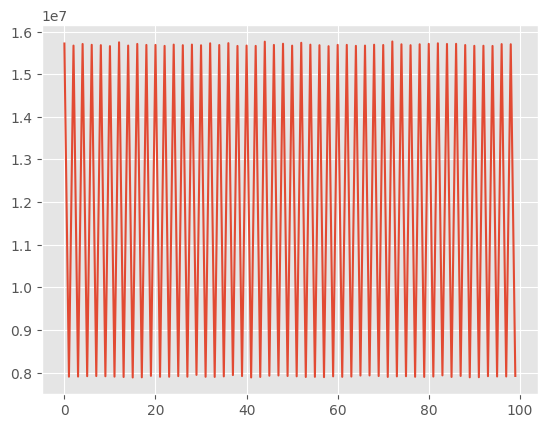

In [4]:
@nw.kernel
def program_probe_out(freq: nw.Var):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    time_line: np.ndarray =np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    envelope_1: nw.Envelope = nw.ins_envelope(0.5 * wave) 
        
    nw.wait_for_trigger()
    nw.play_wave(envelope_0, 1, 0, 0)
    nw.wait(10e-6)
    nw.play_wave(envelope_1, 1, 0, 0)
    
    return nw.kernel

@nw.kernel
def program_probe_in():
    nw.wait_for_trigger()
    nw.capture(2e-6,0,0)
    nw.wait(10e-6)
    nw.capture(2e-6,0,0)
    
    return nw.Kernel

freq = 5.3e9
probe_out_ch = "S2-O1"
probe_in_ch = "S2-I1"
_k_out = program_probe_out(freq)
device.set('ProgramOUT', _k_out, probe_out_ch)
_k_in = program_probe_in()
device.set('ProgramIN', _k_in, probe_in_ch)

device.set("Output", 0, "all")
device.set("Output", 1, probe_out_ch)
device.set("TimeWidth", 2e-6, probe_in_ch)
device.set('FreqList', [freq],probe_in_ch)
device.set('CaptureMode', 0)
device.set("TimeWidth", 2e-6, probe_in_ch) 	##Sets the acquisition time.
shots = 1024
qsync.set('Shot', shots)
device.set('Shot', shots)
device.set('StartCapture')
qsync.set('GenerateTrig', 400e-6)

data = device.get('IQ', probe_in_ch, shots * 2)
data = np.array(data)
data_mean = np.mean(data,axis = 1) 	##Acquires the mean value of the demodulated data.
plt.figure()
x = np.linspace(0,100, 100, endpoint= False)
plt.scatter(x,abs(data[0,:100]))
plt.show()

In [7]:
data.shape

(8, 2048)

### Single Board Feedback

In [85]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_mc = 8e9     # MC Module
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture


# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S3-O1":  da_rate_mc,    # MC channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.5
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


In [92]:
freq = 2.1e9
time_width = 1e-6

device.set('Output', 0, 'all')
for ch in range(8):
    device.set('Output', 1, f'S3-O{ch+1}')

freqs = [freq for _ in range(8)]
for ch in range(4):
    device.set('TimeWidth',1e-6, f'S3-I{ch+1}')
    device.set('FreqList', freqs, f'S3-I{ch+1}')

In [99]:
@nw.kernel
def program_probe_out(freq: nw.Var, time_width: nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope: nw.Envelope = nw.ins_envelope(wave)  
    
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(1e-6)
    nw.wait(100e-9)
    nw.play_wave(envelope, 1, 0, 0)
    
    return nw.Kernel

@nw.kernel
def program_probe_in(time_width: nw.Var):
    judge_reg: nw.Reg = 0 
    nw.set_judge(1+0j, -1000000, [0,1,2,3,4,5,6,7])  # Rotation factor, judgment threshold, and selected frequency points; real[(I + jQ) * (1 + j0)].
    nw.wait_for_trigger()
    nw.wait(1e-6)
    nw.wait(100e-9)
    judge_reg = nw.capture(time_width, 0, 0)  # Acquire the judgment result and assign it to register 0.

    return nw.Kernel

device.set('ProgramIN', program_probe_in(time_width), f'S3-I1')
device.set('ProgramOUT', program_probe_out(freq, time_width), f'S3-O1')

In [94]:
@nw.kernel
def program_xy():
    judge_reg: nw.Reg = 0
    srate: nw.Var = 8e9
    time_width_1: nw.Var = 1e-6
    freq_1: nw.Var = 2.1e9
    time_line_1: np.ndarray =np.linspace(0, time_width_1, int(time_width_1 * srate),endpoint=False)
    wave_1: np.ndarray = np.cos(2 * np.pi * time_line_1 * freq_1)

    time_width_2: nw.Var = 1e-6
    freq_2: nw.Var = 2.1e9
    time_line_2: np.ndarray =np.linspace(0, time_width_2, int(time_width_2 * srate),endpoint=False)
    wave_2: np.ndarray = 0.5 * np.cos(2 * np.pi * time_line_2 * freq_2)
    
    frame: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave_1)
    envelope_2: nw.Envelope = nw.ins_envelope(wave_2)    

    nw.wait_for_trigger()
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.wait(100e-9)
    nw.wait(1e-6)
    nw.wait(1e-6)
    if (judge_reg == 0xff):  # Branch according to the judgment result.
        nw.play_wave(envelope_1, 1, 0, 0)
    else:
        nw.play_wave(envelope_2, 1, 0, 0)
          
    return nw.Kernel

device.set('ProgramOUT', program_xy(), f'S3-O2')   

In [100]:
device.set('CaptureMode', 0)
shots = 1024000
qsync.set('Shot', shots)
device.set('Shot', shots)
# device.set('StartCapture')
qsync.set('GenerateTrig', 100e-6)


In [96]:
device.set('CaptureMode', 0)
shots = 1024
qsync.set('Shot', shots)
device.set('Shot', shots)
device.set('StartCapture')
qsync.set('GenerateTrig', 100e-6)
# Read back IQ data.
IQ_data=device.get("IQ",f'S3-I1',shots)
print(IQ_data)

[[-2772.-2063.j -1533.-1662.j -2119.-2511.j ... -1989.-1974.j
  -1650.-2228.j -1188.-1391.j]
 [-2772.-2063.j -1533.-1662.j -2119.-2511.j ... -1989.-1974.j
  -1650.-2228.j -1188.-1391.j]
 [-2772.-2063.j -1533.-1662.j -2119.-2511.j ... -1989.-1974.j
  -1650.-2228.j -1188.-1391.j]
 ...
 [-2772.-2063.j -1533.-1662.j -2119.-2511.j ... -1989.-1974.j
  -1650.-2228.j -1188.-1391.j]
 [-2772.-2063.j -1533.-1662.j -2119.-2511.j ... -1989.-1974.j
  -1650.-2228.j -1188.-1391.j]
 [-2772.-2063.j -1533.-1662.j -2119.-2511.j ... -1989.-1974.j
  -1650.-2228.j -1188.-1391.j]]


In [ ]:
device.set('CaptureMode', 2)
shots = 1024
qsync.set('Shot', shots)
device.set('Shot', shots)
device.set('StartCapture')
qsync.set('GenerateTrig', 100e-6)
# Read back judgment data.
judge_data=device.get("Judgment",f'S3-I1',shots)
print(judge_data)

In [643]:
qsync.set("ResetTrig")

### Inter-board Feedback

In [101]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture


# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.5
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


In [102]:
probe_in_ch = 'S2-I1'
probe_out_ch = 'S2-O1'
xy_ch = 'S13-O1'
xy_freq = 0.1e9
probe_freq = 2.1e9
xy_width = 1e-6
probe_width = 1e-6

In [103]:
device.set('Output', 0, 'all')
device.set('Output', 1, probe_out_ch)
device.set('Output', 1, xy_ch)

In [104]:
freqs = [probe_freq for _ in range(8)]
for ch in range(4):
    device.set('TimeWidth',1e-6, f'S2-I{ch+1}')
    device.set('FreqList', freqs, f'S2-I{ch+1}')

In [105]:
qsync.set('GT_pd',1)

In [106]:
port_name1 = probe_out_ch
device.set('CustomALite', [0x01F0_0000+2*4, 1], port_name1)
time.sleep(1e-5)
device.set('CustomALite', [0x01F0_0000+2*4, 0], port_name1)
time.sleep(3)

port_name2 = xy_ch

device.set('CustomALite', [0x01F0_0000+2*4, 1], port_name2)
time.sleep(1e-5)
device.set('CustomALite', [0x01F0_0000+2*4, 0], port_name2)
time.sleep(1e-5)

In [107]:
device.set("TerminateUpload")

In [108]:
device.set('SetRoute', [probe_out_ch, xy_ch])  # 把IN-1通道的反馈消息传递给OUT1 rd 只能插在s9

In [116]:
@nw.kernel
def program_xy(freq:nw.Var, time_width:nw.Var):
    judge_reg: nw.Reg = 0
    srate: nw.Var = 8e9
    wave: np.ndarray = np.ones(round(time_width * srate))
    
    frame: nw.Frame = nw.init_frame(freq, 0.5*np.pi)
    envelope: nw.Envelope = nw.ins_envelope(wave) 

    nw.wait_for_trigger()
    nw.play_wave(envelope, 1, 0, 0)
    nw.wait(100e-9)
    nw.wait(1e-6)
    nw.wait(1e-6)
    judge_reg = nw.receive(1)  # 获取广播的判决结果并存入寄存器
    if (judge_reg == 0xff): # 判决
        nw.play_wave(envelope, 1, 0, 0)
    else:
        nw.play_wave(envelope, 0.5, 0, 0)
          
    return nw.Kernel

device.set('ProgramOUT', program_xy(xy_freq, xy_width), xy_ch)   

In [118]:
@nw.kernel
def program_probe_out(freq:nw.Var, time_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope: nw.Envelope = nw.ins_envelope(wave)  
    
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(1e-6)
    nw.wait(100e-9)
    nw.play_wave(envelope, 1, 0, 0)
    
    return nw.Kernel

@nw.kernel
def program_probe_in(probe_width:nw.Var):
    judge_reg: nw.Reg = 0 
    nw.set_judge(1+0j, -100000000, [0,1,2,3,4,5,6,7])  # 旋转因子，判决门限，频点选择 # real[(I+jQ)(1+j0)]
    nw.wait_for_trigger()
    nw.wait(1e-6)
    nw.wait(100e-9)
    judge_reg = nw.capture(probe_width, 0, 0)  # 采集判决结果并赋值给寄存器0
    nw.send(judge_reg)

    return nw.Kernel

device.set('ProgramIN', program_probe_in(probe_width), probe_in_ch)
device.set('ProgramOUT', program_probe_out(probe_freq, probe_width), probe_out_ch)

In [113]:
device.set('CaptureMode', 0)
shots = 1024
qsync.set('Shot', shots)
device.set('Shot', shots)
device.set('StartCapture')
qsync.set('GenerateTrig', 100e-6)
# Read back IQ data.
IQ_data=device.get("IQ",f'S2-I1',shots)
print(IQ_data)

[[-1324.-2069.j -1690.-1938.j -2376.-1962.j ... -1634.-1836.j
  -2115.-2437.j -1860.-1635.j]
 [-1324.-2069.j -1690.-1938.j -2376.-1962.j ... -1634.-1836.j
  -2115.-2437.j -1860.-1635.j]
 [-1324.-2069.j -1690.-1938.j -2376.-1962.j ... -1634.-1836.j
  -2115.-2437.j -1860.-1635.j]
 ...
 [-1324.-2069.j -1690.-1938.j -2376.-1962.j ... -1634.-1836.j
  -2115.-2437.j -1860.-1635.j]
 [-1324.-2069.j -1690.-1938.j -2376.-1962.j ... -1634.-1836.j
  -2115.-2437.j -1860.-1635.j]
 [-1324.-2069.j -1690.-1938.j -2376.-1962.j ... -1634.-1836.j
  -2115.-2437.j -1860.-1635.j]]


In [409]:
qsync.set("ResetTrig")

In [410]:
device.set('CaptureMode', 2)
shots = 1024
qsync.set('Shot', shots)
device.set('Shot', shots)
device.set('StartCapture')
qsync.set('GenerateTrig', 100e-6)
#########判决数据上行
judge_data=device.get("Judgment", probe_in_ch, shots)
print(judge_data)

[255 255 255 ... 255 255 255]


## Experiment Example of the Instructions Set Control Mode

### S21

Experiments Introduction  
The S21 experiment is used to sweep the resonant frequency of a readout cavity in a superconducting quantum system. This example demonstrates how to use NSQDriver with a PowerQuantum device in instruction set control mode to play a probe signal, demodulate the returned signal, and obtain the cavity transmission response.

Experiment Steps
The following steps demonstrate how to perform a cavity resonant frequency sweep using instruction set control:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the readout output channel, readout input channel, frequency sweep range, pulse width, amplitude, shots, trigger period, and timing parameters.
3. Build the instruction program for probe waveform playback and demodulated capture.
4. Configure output enable, capture mode, capture time width, demodulation frequency, and input delay.
5. For each probe frequency, update the waveform and demodulation frequency settings.
6. Start capture, generate the trigger, and execute the instruction program.
7. Acquire and average the demodulated IQ data.
8. Calculate the S21 amplitude in dB and plot the cavity transmission curve.

In [126]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


S21 sweep:   0%|          | 0/101 [00:00<?, ?it/s]

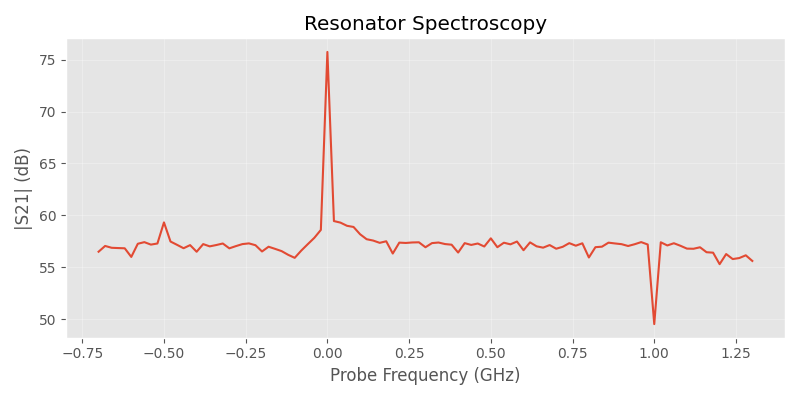

In [127]:
# ============================================================
# Resonator Spectroscopy
# S21 frequency sweep in instruction mode
# Instruction timing granularity: 4 ns
# ============================================================

# ---------- 0. Timing alignment ----------
INST_STEP = 4e-9    # instruction timing granularity

def align4(t):
    return round(t / INST_STEP) * INST_STEP


# ---------- 1. nswave kernels ----------
@nw.kernel
def program_probe_in(capture_start: nw.Var, capture_width: nw.Var):
    nw.wait_for_trigger()
    nw.wait(capture_start)
    nw.capture(capture_width, 0, 0)

    return nw.Kernel


@nw.kernel
def program_probe_out(probe_freq: nw.Var, probe_width: nw.Var, probe_amp: nw.Var, probe_out_start: nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(
        0,
        probe_width,
        int(round(probe_width * srate)),
        endpoint=False,
    )
    probe_wave: np.ndarray = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)

    frame: nw.Frame = nw.init_frame(0, 0.5 * np.pi)
    probe_envelope: nw.Envelope = nw.ins_envelope(probe_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(probe_out_start)
    nw.play_wave(probe_envelope, 1, 0, 0)

    return nw.Kernel


# ---------- 2. Channel and sweep parameters ----------
probe_out_ch    = "S2-O1"                       # readout probe output channel
probe_in_ch     = "S2-I1"                       # readout demod input channel

probe_freq      = 0.3e9                         # resonator probe frequency center (Hz)
band            = 2e9                           # sweep bandwidth (Hz)

probe_freq_list = np.linspace(
    probe_freq - band / 2,
    probe_freq + band / 2,
    101,
)                                               # probe frequency sweep list (Hz)

shots           = 1024                          # averages per frequency point
trig_period     = 50e-6                         # qsync trigger period (s)
cap_num         = 1                             # number of captures per shot

probe_width     = align4(2e-6)                  # readout probe pulse duration (s)
probe_amp       = 1.0                           # probe pulse amplitude (normalized)

probe_out_start = align4(0)                     # probe pulse output start time (s)
probe_in_start  = align4(100e-9)                # probe signal capture start time (s)


# ---------- 3. Static device configuration ----------
device.set("CaptureMode", 0)
device.set("Shot", int(shots))

qsync.set("Shot", int(shots))
qsync.set("TrigPeriod", trig_period)

device.set(
    "ProgramIN",
    program_probe_in(probe_in_start, probe_width),
    probe_in_ch,
)


# ---------- 4. Frequency sweep capture ----------
s21_iq_list = []

for probe_freq in tqdm(probe_freq_list, desc="S21 sweep"):

    device.set("FreqList", [float(probe_freq)], probe_in_ch)  # configure demodulation frequency

    device.set(
        "ProgramOUT",
        program_probe_out(probe_freq, probe_width, probe_amp, probe_out_start),
        probe_out_ch,
    )                                                        # download probe output program

    device.set("StartCapture")                              # start capture
    qsync.set("GenerateTrig")                               # fire trigger

    iq_data = device.get("IQ", probe_in_ch, round(shots * cap_num))
    cap_data = iq_data[0, 0::cap_num]                       # select the first capture of each shot

    s21_iq_list.append(cap_data)


# ---------- 5. Data processing and plotting ----------
s21_iq_arr = np.array(s21_iq_list)                           # (freq, shots)
s21_complex = s21_iq_arr.mean(axis=1)                        # -> (freq,)
s21_db = 20 * np.log10(np.abs(s21_complex))                  # amplitude to dB

plt.figure(figsize=(8, 4))
plt.plot(probe_freq_list / 1e9, s21_db)
plt.xlabel("Probe Frequency (GHz)")
plt.ylabel("|S21| (dB)")
plt.title("Resonator Spectroscopy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(-4.0, 4.0)

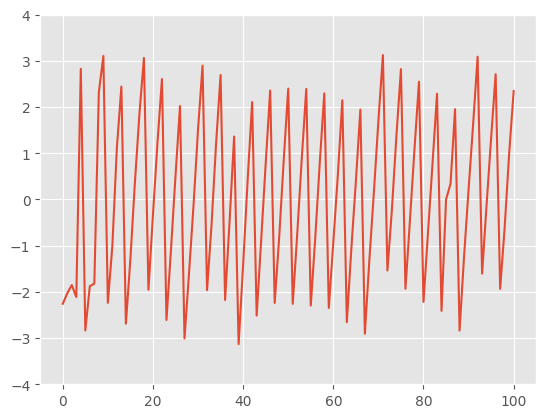

In [827]:
# 因为有一个固定延迟，因此相位随着频率变化，若要矫正可使用电延迟矫正
plt.figure()
rabi_phis = np.angle(s21_complex)
plt.plot(rabi_phis)
plt.ylim([-4,4])

### S21 vs Power

Experiments Introduction  
The S21 vs Power experiment is used to measure the cavity transmission response under different readout powers in a superconducting quantum system. This example demonstrates how to use instruction set control to sweep both probe frequency and probe amplitude, helping evaluate readout power dependence and cavity response linearity.

Experiment Steps
The following steps demonstrate how to perform a two-dimensional S21 sweep versus readout power:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the readout output channel, readout input channel, probe frequency list, probe power list, pulse width, shots, trigger period, and timing parameters.
3. Build the instruction program for probe waveform playback and demodulated capture.
4. Configure output enable, capture mode, capture time width, demodulation frequency, and input delay.
5. For each probe power, scale the probe waveform amplitude.
6. For each probe frequency, execute the instruction program, start capture, and generate the trigger.
7. Acquire and average demodulated IQ data.
8. Convert the response to dB and plot the S21 map versus frequency and readout power.

In [124]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


Power sweep:   0%|          | 0/21 [00:00<?, ?it/s]

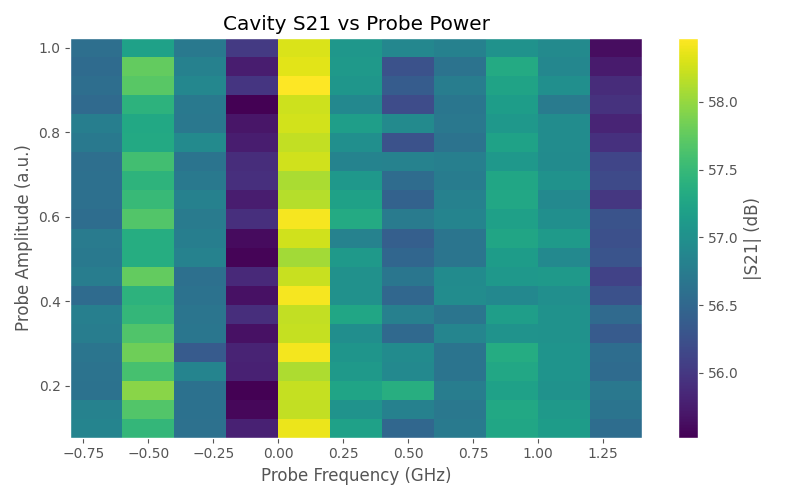

In [125]:
# ============================================================
# Resonator Spectroscopy
# S21 vs Probe Power in instruction mode
# Instruction timing granularity: 4 ns
# ============================================================

# ---------- 0. Timing alignment ----------
INST_STEP = 4e-9    # instruction timing granularity

def align4(t):
    return round(t / INST_STEP) * INST_STEP


# ---------- 1. nswave kernels ----------
@nw.kernel
def program_probe_in(capture_start: nw.Var, capture_width: nw.Var):
    nw.wait_for_trigger()
    nw.wait(capture_start)
    nw.capture(capture_width, 0, 0)

    return nw.Kernel


@nw.kernel
def program_probe_out(probe_freq: nw.Var, probe_width: nw.Var, probe_amp: nw.Var, probe_out_start: nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(
        0,
        probe_width,
        int(round(probe_width * srate)),
        endpoint=False,
    )
    probe_wave: np.ndarray = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)

    frame: nw.Frame = nw.init_frame(0, 0.5 * np.pi)
    probe_envelope: nw.Envelope = nw.ins_envelope(probe_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(probe_out_start)
    nw.play_wave(probe_envelope, 1, 0, 0)

    return nw.Kernel


# ---------- 2. Channel and sweep parameters ----------
probe_out_ch     = "S2-O1"                       # readout probe output channel
probe_in_ch      = "S2-I1"                       # readout demod input channel

probe_freq       = 0.3e9                         # resonator probe frequency center (Hz)
band             = 2e9                           # sweep bandwidth (Hz)

probe_freq_list  = np.linspace(
    probe_freq - band / 2,
    probe_freq + band / 2,
    11,
)                                                # probe frequency sweep list (Hz)

probe_amp_list   = np.linspace(0.1, 1, 21)         # probe amplitude sweep list

shots            = 1024                          # averages per frequency point
trig_period      = 50e-6                         # qsync trigger period (s)
cap_num          = 1                             # number of captures per shot

probe_width      = align4(2e-6)                  # readout probe pulse duration (s)
probe_out_start  = align4(0)                     # probe pulse output start time (s)
probe_in_start   = align4(100e-9)                # probe signal capture start time (s)


# ---------- 3. Static device configuration ----------
device.set("CaptureMode", 0)
device.set("Shot", int(shots))

qsync.set("Shot", int(shots))
qsync.set("TrigPeriod", trig_period)

device.set(
    "ProgramINSrc",
    program_probe_in(probe_in_start, probe_width),
    probe_in_ch,
)


# ---------- 4. Power and frequency sweep capture ----------
s21_iq_power_list = []

for probe_amp in tqdm(probe_amp_list, desc="Power sweep"):

    s21_iq_list = []

    for probe_freq in probe_freq_list:

        device.set("FreqList", [float(probe_freq)], probe_in_ch)  # configure demodulation frequency

        device.set(
            "ProgramOUTSrc",
            program_probe_out(probe_freq, probe_width, probe_amp, probe_out_start),
            probe_out_ch,
        )                                                        # download probe output program

        device.set("StartCapture")                              # start capture
        qsync.set("GenerateTrig")                               # fire trigger

        iq_data = device.get("IQ", probe_in_ch, round(shots * cap_num))
        cap_data = iq_data[0, 0::cap_num]                       # select the first capture of each shot

        s21_iq_list.append(cap_data)

    s21_iq_power_list.append(s21_iq_list)


# ---------- 5. Data processing and plotting ----------
s21_iq_power_arr = np.array(s21_iq_power_list)                   # (power, freq, shots)
s21_complex = s21_iq_power_arr.mean(axis=2)                      # -> (power, freq)
s21_power_db = 20 * np.log10(np.abs(s21_complex))                # amplitude to dB

plt.figure(figsize=(8, 5))
plt.pcolormesh(
    probe_freq_list / 1e9,
    probe_amp_list,
    s21_power_db,
    shading="auto",
    cmap="viridis",
)
plt.colorbar(label="|S21| (dB)")
plt.xlabel("Probe Frequency (GHz)")
plt.ylabel("Probe Amplitude (a.u.)")
plt.title("Cavity S21 vs Probe Power")
plt.tight_layout()
plt.show()

(-4.0, 4.0)

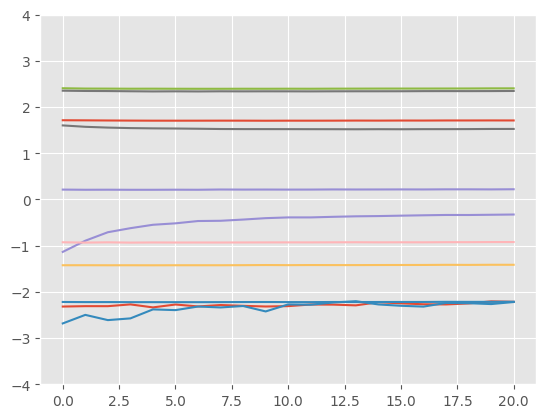

In [832]:
# 滤波器是5.2-7.8GHz，相位图正常
plt.figure()
rabi_phis = np.angle(s21_complex)
plt.plot(rabi_phis)
plt.ylim([-4,4])

### Spectrum

Experiments Introduction  
The Spectrum experiment is used to find the transition frequency of a superconducting qubit. This example demonstrates how to use instruction set control to sweep the XY drive frequency while using a fixed readout pulse to measure the qubit-state-dependent cavity response.

Experiment Steps
The following steps demonstrate how to perform a qubit spectroscopy sweep:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, readout output channel, readout input channel, XY frequency list, probe frequency, pulse widths, amplitudes, shots, trigger period, and timing offsets.
3. Build the instruction program for the readout pulse and demodulated acquisition.
4. Build the instruction program for the XY drive pulse.
5. Configure output, capture mode, trigger period, demodulation frequency, and timing alignment.
6. For each XY drive frequency, execute the drive pulse and then perform readout.
7. Acquire and average the demodulated IQ data at each frequency point.
8. Plot the spectrum response versus XY drive frequency to identify the qubit transition.

In [128]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


Qubit Spectroscopy:   0%|          | 0/101 [00:00<?, ?it/s]

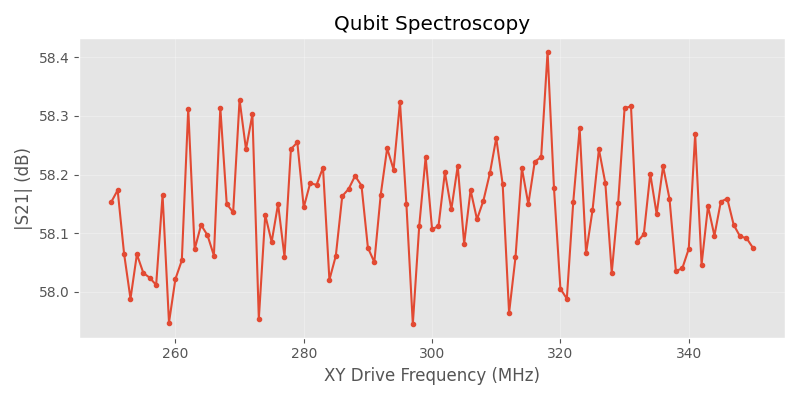

In [129]:
# ============================================================
# Qubit Spectroscopy
# XY frequency sweep with a fixed square-envelope XY pulse
# Instruction timing granularity: 4 ns
# ============================================================

# ---------- 0. Timing alignment ----------
INST_STEP = 4e-9    # instruction timing granularity

def align4(t):
    return round(t / INST_STEP) * INST_STEP


# ---------- 1. nswave kernels ----------
@nw.kernel
def program_probe_in(capture_start: nw.Var, capture_width: nw.Var):
    nw.wait_for_trigger()
    nw.wait(capture_start)
    nw.capture(capture_width, 0, 0)

    return nw.Kernel


@nw.kernel
def program_probe_out(probe_freq: nw.Var, probe_width: nw.Var, probe_amp: nw.Var, probe_out_start: nw.Var):
    srate: nw.Var = 8e9
    probe_time: np.ndarray = np.linspace(
        0,
        probe_width,
        int(round(probe_width * srate)),
        endpoint=False,
    )
    probe_wave: np.ndarray = np.cos(2 * np.pi * probe_freq * probe_time)

    frame: nw.Frame = nw.init_frame(0, 0.5 * np.pi)
    probe_envelope: nw.Envelope = nw.ins_envelope(probe_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(probe_out_start)
    nw.play_wave(probe_envelope, probe_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_drive(drive_freq: nw.Var, drive_width: nw.Var, drive_amp: nw.Var):
    srate: nw.Var = 8e9
    drive_wave: np.ndarray = np.ones(int(round(drive_width * srate)))

    frame: nw.Frame = nw.init_frame(drive_freq, 0.5 * np.pi)
    drive_envelope: nw.Envelope = nw.ins_envelope(drive_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(drive_envelope, drive_amp, 0, 0)

    return nw.Kernel


# ---------- 2. Channel and sweep parameters ----------
xy_ch          = "S13-O1"                       # XY drive output channel
probe_out_ch   = "S2-O1"                        # readout probe output channel
probe_in_ch    = "S2-I1"                        # readout demod input channel

xy_freq_center = 0.3e9                          # XY drive sweep center frequency (Hz)
probe_freq     = 0.1e9                          # resonator probe frequency (Hz)

xy_freq_list   = np.linspace(
    xy_freq_center - 50e6,
    xy_freq_center + 50e6,
    101,
)                                               # XY drive frequency sweep list (Hz)

shots          = 1024                           # averages per frequency point
trig_period    = 500e-6                         # qsync trigger period (s)
cap_num        = 1                              # number of captures per shot

probe_width    = align4(2e-6)                   # readout probe pulse duration (s)
drive_width    = align4(1e-6)                   # XY drive pulse duration (s)

xy_amp         = 1.0                            # XY drive amplitude (normalized)
probe_amp      = 1.0                            # probe pulse amplitude (normalized)

xy_margin      = align4(0.1e-6)                 # buffer after XY drive before readout
readout_gap    = align4(100e-9)                 # delay from XY window end to probe output
capture_gap    = align4(400e-9)                 # delay from probe output to capture start

# Define all pulse timings on a common trigger-based time axis.
drive_window    = align4(drive_width + xy_margin)
probe_out_start = align4(drive_window + readout_gap)
probe_in_start  = align4(probe_out_start + capture_gap)

# Demodulation frequency list.
# Here all demod channels use the same probe frequency.
demod_freq_list = [float(probe_freq)] * 8


# ---------- 3. Static device configuration ----------
device.set("CaptureMode", 0)
device.set("Shot", int(shots))
device.set("FreqList", demod_freq_list, probe_in_ch)

device.set("Output", 1, xy_ch)
device.set("Output", 1, probe_out_ch)

qsync.set("Shot", int(shots))
qsync.set("TrigPeriod", trig_period)

# Configure the fixed readout capture program.
device.set(
    "ProgramIN",
    program_probe_in(probe_in_start, probe_width),
    probe_in_ch,
)

# Configure the fixed readout output program.
device.set(
    "ProgramOUT",
    program_probe_out(probe_freq, probe_width, probe_amp, probe_out_start),
    probe_out_ch,
)


# ---------- 4. Frequency sweep capture ----------
spectrum_iq_list = []

for xy_freq in tqdm(xy_freq_list, desc="Qubit Spectroscopy"):

    # XY drive pulse at the current sweep frequency
    device.set(
        "ProgramOUT",
        program_drive(xy_freq, drive_width, xy_amp),
        xy_ch,
    )                                                   # download XY drive program

    device.set("StartCapture")                         # start capture
    qsync.set("GenerateTrig")                          # fire trigger

    iq_data = device.get("IQ", probe_in_ch, round(shots * cap_num))
    cap_data = iq_data[:, 0::cap_num]                  # select the first capture of each shot

    spectrum_iq_list.append(cap_data)


# ---------- 5. Data processing and plotting ----------
spectrum_iq_arr = np.array(spectrum_iq_list)            # (freq, n_demod, shots)
spectrum_complex = spectrum_iq_arr.mean(axis=2)         # -> (freq, n_demod)
spectrum_db = 20 * np.log10(np.abs(spectrum_complex))   # amplitude to dB

plt.figure(figsize=(8, 4))
plt.plot(xy_freq_list / 1e6, spectrum_db[:, 0], marker="o", markersize=3)
plt.xlabel("XY Drive Frequency (MHz)")
plt.ylabel("|S21| (dB)")
plt.title("Qubit Spectroscopy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(-4.0, 4.0)

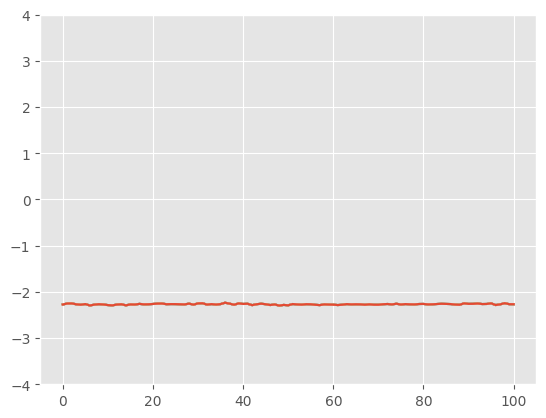

In [823]:
# 固定频率，相位不变
plt.figure()
rabi_phis = np.angle(spectrum_complex)
plt.plot(rabi_phis)
plt.ylim([-4,4])
# plt.show()

### Spectrum vs Flux

Experiments Introduction  
The Spectrum vs Flux experiment is used to measure how the transition frequency of a superconducting qubit changes with flux bias. This example demonstrates how to use instruction set control to sweep the XY drive frequency while stepping the Z bias amplitude, producing a two-dimensional qubit spectrum map.

Experiment Steps
The following steps demonstrate how to perform a qubit spectroscopy measurement versus flux bias:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, XY frequency list, bias list, pulse widths, amplitudes, and timing offsets.
3. Build the instruction program for the readout pulse and demodulated acquisition.
4. Build the instruction programs for the XY drive pulse and Z bias waveform.
5. Configure output, capture mode, trigger period, demodulation frequency, and timing alignment.
6. For each flux-bias point, apply the Z bias waveform.
7. For each XY frequency, play the drive pulse, perform readout, and acquire demodulated IQ data.
8. Average and normalize the IQ data, then plot the qubit spectrum as a function of XY frequency and flux bias.

In [130]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


Qubit Spectroscopy:   0%|          | 0/11 [00:00<?, ?it/s]

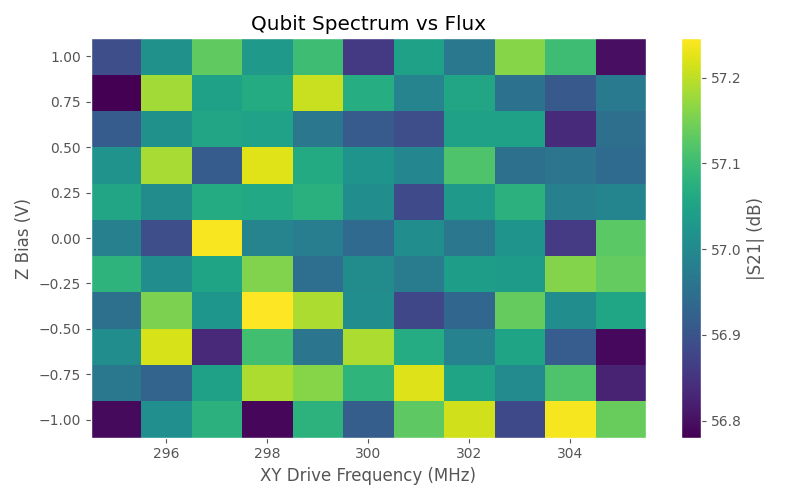

In [131]:
# ============================================================
# Qubit Spectrum vs Flux
# XY frequency sweep and Z bias sweep in instruction mode
# Instruction timing granularity: 4 ns
# ============================================================

# ---------- 0. Timing alignment ----------
INST_STEP = 4e-9    # instruction timing granularity

def align4(t):
    return round(t / INST_STEP) * INST_STEP


# ---------- 1. nswave kernels ----------
@nw.kernel
def program_probe_in(capture_start: nw.Var, capture_width: nw.Var):
    nw.wait_for_trigger()
    nw.wait(capture_start)
    nw.capture(capture_width, 0, 0)

    return nw.Kernel


@nw.kernel
def program_probe_out(
    probe_freq: nw.Var,
    probe_width: nw.Var,
    probe_amp: nw.Var,
    probe_out_start: nw.Var,
):
    srate: nw.Var = 8e9
    probe_time: np.ndarray = np.linspace(
        0,
        probe_width,
        int(round(probe_width * srate)),
        endpoint=False,
    )
    probe_wave: np.ndarray = np.cos(2 * np.pi * probe_freq * probe_time)

    frame: nw.Frame = nw.init_frame(0, 0.5 * np.pi)
    probe_envelope: nw.Envelope = nw.ins_envelope(probe_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(probe_out_start)
    nw.play_wave(probe_envelope, probe_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_drive(
    drive_freq: nw.Var,
    drive_width: nw.Var,
    drive_amp: nw.Var,
    xy_margin: nw.Var,
):
    srate: nw.Var = 8e9
    drive_wave: np.ndarray = np.ones(int(round(drive_width * srate)))

    frame: nw.Frame = nw.init_frame(drive_freq, 0.5 * np.pi)
    drive_envelope: nw.Envelope = nw.ins_envelope(drive_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(xy_margin)
    nw.play_wave(drive_envelope, drive_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_z(z_width: nw.Var, bias: nw.Var):
    srate: nw.Var = 4e9
    z_wave: np.ndarray = bias * np.ones(int(round(z_width * srate)))

    z_envelope: nw.Envelope = nw.ins_envelope(z_wave)

    nw.wait_for_trigger()
    nw.play_wave(z_envelope, 1, 0, 0)

    return nw.Kernel


# ---------- 2. Channel and sweep parameters ----------
xy_ch          = "S13-O1"                       # XY drive output channel
z_ch           = "S12-O1"                       # Z bias output channel
probe_out_ch   = "S2-O1"                        # readout probe output channel
probe_in_ch    = "S2-I1"                        # readout demod input channel

xy_freq_center = 0.3e9                          # XY drive sweep center frequency (Hz)
probe_freq     = 0.3e9                          # resonator probe frequency (Hz)

xy_freq_list   = np.linspace(
    xy_freq_center - 5e6,
    xy_freq_center + 5e6,
    11,
)                                               # XY drive frequency sweep list (Hz)

bias_list      = np.linspace(-1, 1, 11)         # Z bias sweep list (V)

shots          = 1024                           # averages per sweep point
trig_period    = 500e-6                         # qsync trigger period (s)
cap_num        = 1                              # number of captures per shot

probe_width    = align4(2e-6)                   # readout probe pulse duration (s)
drive_width    = align4(1e-6)                   # XY drive pulse duration (s)

xy_amp         = 1.0                            # XY drive amplitude (normalized)
probe_amp      = 1.0                            # probe pulse amplitude (normalized)

xy_margin      = align4(0.1e-6)                 # buffer before XY drive
readout_gap    = align4(200e-9)                 # delay from XY pulse end to probe output
capture_gap    = align4(400e-9)                 # delay from probe output to capture start

# Common trigger-based timing.
xy_start        = xy_margin
xy_end          = align4(xy_start + drive_width)
probe_out_start = align4(xy_end + readout_gap)
probe_in_start  = align4(probe_out_start + capture_gap)

# Z bias covers XY pulse, readout pulse, capture window, and final margin.
z_width         = align4(probe_in_start + probe_width + xy_margin)

demod_freq_list = [float(probe_freq)] * 8       # demodulation frequency list


# ---------- 3. Static device configuration ----------
device.set("CaptureMode", 0)
device.set("Shot", int(shots))
device.set("FreqList", demod_freq_list, probe_in_ch)

device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Output", 1, probe_out_ch)

qsync.set("Shot", int(shots))
qsync.set("TrigPeriod", trig_period)

device.set(
    "ProgramIN",
    program_probe_in(probe_in_start, probe_width),
    probe_in_ch,
)

device.set(
    "ProgramOUT",
    program_probe_out(probe_freq, probe_width, probe_amp, probe_out_start),
    probe_out_ch,
)


# ---------- 4. Frequency and bias sweep capture ----------
spectrum_2d = []

for xy_freq in tqdm(xy_freq_list, desc="Qubit Spectroscopy"):

    device.set(
        "ProgramOUT",
        program_drive(xy_freq, drive_width, xy_amp, xy_margin),
        xy_ch,
    )                                                   # download XY drive program

    spectrum_row = []

    for bias in bias_list:

        device.set(
            "ProgramOUT",
            program_z(z_width, bias),
            z_ch,
        )                                               # download Z bias program

        device.set("StartCapture")                     # start capture
        qsync.set("GenerateTrig")                      # fire trigger

        iq_data = device.get("IQ", probe_in_ch, round(shots * cap_num))
        cap_data = iq_data[:, 0::cap_num]              # (n_demod, shots)

        spectrum_row.append(cap_data)

    spectrum_2d.append(spectrum_row)


# ---------- 5. Data processing and plotting ----------
spectrum_2d_arr = np.array(spectrum_2d)                 # (freq, bias, n_demod, shots)
spectrum_2d_complex = spectrum_2d_arr.mean(axis=3)      # -> (freq, bias, n_demod)
spectrum_2d_db = 20 * np.log10(np.abs(spectrum_2d_complex[:, :, 0]))

plt.figure(figsize=(8, 5))
plt.pcolormesh(
    xy_freq_list / 1e6,
    bias_list,
    spectrum_2d_db.T,
    shading="auto",
    cmap="viridis",
)
plt.colorbar(label="|S21| (dB)")
plt.xlabel("XY Drive Frequency (MHz)")
plt.ylabel("Z Bias (V)")
plt.title("Qubit Spectrum vs Flux")
plt.tight_layout()
plt.show()

(-4.0, 4.0)

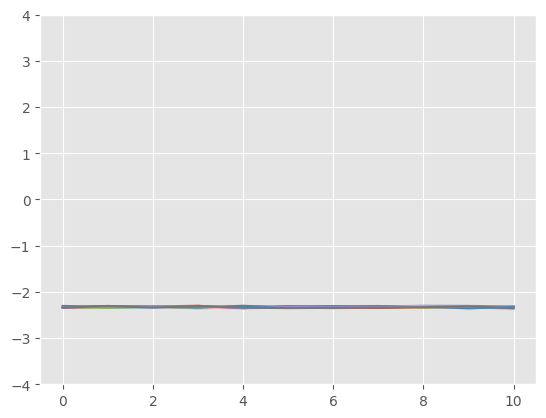

In [253]:
plt.figure()
rabi_phis = np.angle(spectrum_2d_complex[:,:,0])
plt.plot(rabi_phis)
plt.ylim([-4,4])

### Power Rabi

Experiments Introduction  
The Power Rabi experiment is used to calibrate the pulse amplitude required to rotate a superconducting qubit by a desired angle. This example demonstrates how to use instruction set control to sweep the XY drive amplitude while keeping the pulse duration and drive frequency fixed.

Experiment Steps
The following steps demonstrate how to perform a Power Rabi measurement:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, amplitude list, drive frequency, pulse width, and readout parameters.
3. Build the instruction program for the readout pulse and demodulated acquisition.
4. Build the instruction program for the XY drive pulse with variable amplitude.
5. Configure output, capture mode, trigger period, demodulation frequency, and timing alignment.
6. For each drive amplitude, execute the XY pulse sequence and then perform readout.
7. Acquire and average IQ data at each amplitude point.
8. Plot the qubit response versus drive amplitude and determine the pi-pulse and half-pi-pulse amplitudes.

In [135]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


Power Rabi:   0%|          | 0/21 [00:00<?, ?it/s]

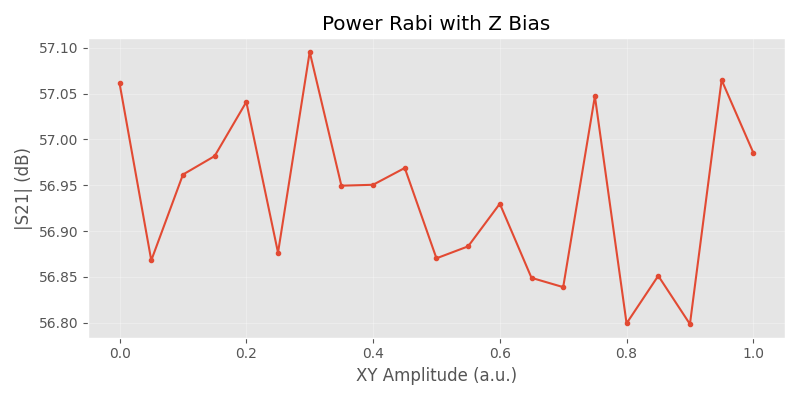

In [136]:
# ============================================================
# Power Rabi
# XY amplitude sweep with Z flux bias in instruction mode
# Instruction timing granularity: 4 ns
# ============================================================

# ---------- 0. Timing alignment ----------
INST_STEP = 4e-9    # instruction timing granularity

def align4(t):
    return round(t / INST_STEP) * INST_STEP


# ---------- 1. nswave kernels ----------
@nw.kernel
def program_cap(capture_start: nw.Var, capture_width: nw.Var):
    nw.wait_for_trigger()
    nw.wait(capture_start)
    nw.capture(capture_width, 0, 0)

    return nw.Kernel


@nw.kernel
def program_probe_out(
    probe_freq: nw.Var,
    probe_width: nw.Var,
    probe_amp: nw.Var,
    probe_out_start: nw.Var,
):
    srate: nw.Var = 8e9
    probe_time: np.ndarray = np.linspace(
        0,
        probe_width,
        int(round(probe_width * srate)),
        endpoint=False,
    )
    probe_wave: np.ndarray = np.cos(2 * np.pi * probe_freq * probe_time)

    frame: nw.Frame = nw.init_frame(0, 0.5 * np.pi)
    probe_envelope: nw.Envelope = nw.ins_envelope(probe_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(probe_out_start)
    nw.play_wave(probe_envelope, probe_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_drive(
    drive_freq: nw.Var,
    drive_width: nw.Var,
    drive_amp: nw.Var,
    z_margin: nw.Var,
):
    srate: nw.Var = 8e9
    drive_wave: np.ndarray = np.ones(int(round(drive_width * srate)))

    frame: nw.Frame = nw.init_frame(drive_freq, 0)
    drive_envelope: nw.Envelope = nw.ins_envelope(drive_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(z_margin)
    nw.play_wave(drive_envelope, drive_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_z(z_width: nw.Var, z_amp: nw.Var):
    srate: nw.Var = 4e9
    z_wave: np.ndarray = z_amp * np.ones(int(round(z_width * srate)))

    z_envelope: nw.Envelope = nw.ins_envelope(z_wave)

    nw.wait_for_trigger()
    nw.play_wave(z_envelope, 1, 0, 0)

    return nw.Kernel


# ---------- 2. Channel and sweep parameters ----------
xy_ch          = "S13-O1"                       # XY drive output channel
z_ch           = "S12-O1"                       # Z flux bias output channel
probe_out_ch   = "S2-O1"                        # readout probe output channel
probe_in_ch    = "S2-I1"                        # readout demod input channel

xy_freq        = 0.1e9                          # XY drive frequency (Hz)
probe_freq     = 0.3e9                          # resonator probe frequency (Hz)

drive_width    = align4(1e-6)                   # fixed XY pulse width
xy_amp_list    = np.linspace(0, 1, 21)           # XY amplitude sweep list

probe_amp      = 1.0                            # probe pulse amplitude
z_amp          = 1.0                            # constant Z bias amplitude

shots          = 1024                           # averages per amplitude point
trig_period    = 800e-6                         # qsync trigger period (s)
cap_num        = 1                              # number of captures per shot

probe_width    = align4(2e-6)                   # readout probe pulse duration
z_margin       = align4(96e-9)                  # Z margin before/after XY pulse

readout_gap    = align4(300e-9)                 # delay from XY pulse end to probe output
capture_gap    = align4(220e-9)                 # delay from probe output to capture start

# Common trigger-based timing.
xy_start        = z_margin
xy_end          = align4(xy_start + drive_width)
probe_out_start = align4(xy_end + readout_gap)
probe_in_start  = align4(probe_out_start + capture_gap)

# Z bias covers XY pulse, readout pulse, capture window, and final margin.
z_width         = align4(probe_in_start + probe_width + z_margin)

demod_freq_list = [float(probe_freq)] * 8       # demodulation frequency list


# ---------- 3. Static device configuration ----------
device.set("CaptureMode", 0)
device.set("Shot", int(shots))
device.set("FreqList", demod_freq_list, probe_in_ch)

device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Output", 1, probe_out_ch)

qsync.set("Shot", int(shots))
qsync.set("TrigPeriod", trig_period)

device.set(
    "ProgramOUT",
    program_z(z_width, z_amp),
    z_ch,
)                                                   # download Z bias program

device.set(
    "ProgramIN",
    program_cap(probe_in_start, probe_width),
    probe_in_ch,
)                                                   # download capture program

device.set(
    "ProgramOUT",
    program_probe_out(probe_freq, probe_width, probe_amp, probe_out_start),
    probe_out_ch,
)                                                   # download probe output program


# ---------- 4. Amplitude sweep capture ----------
rabi_iq_list = []

for xy_amp in tqdm(xy_amp_list, desc="Power Rabi"):

    device.set(
        "ProgramOUT",
        program_drive(xy_freq, drive_width, xy_amp, z_margin),
        xy_ch,
    )                                               # download XY drive program

    device.set("StartCapture")                     # start capture
    qsync.set("GenerateTrig")                      # fire trigger

    iq_data = device.get("IQ", probe_in_ch, round(shots * cap_num))
    cap_data = iq_data[:, 0::cap_num]              # select the first capture of each shot

    rabi_iq_list.append(cap_data)


# ---------- 5. Data processing and plotting ----------
rabi_iq_arr = np.array(rabi_iq_list)                # (amp, n_demod, shots)
rabi_complex = rabi_iq_arr.mean(axis=2)             # -> (amp, n_demod)
rabi_db = 20 * np.log10(np.abs(rabi_complex))       # amplitude to dB

plt.figure(figsize=(8, 4))
plt.plot(xy_amp_list, rabi_db[:, 0], marker="o", markersize=3)
plt.xlabel("XY Amplitude (a.u.)")
plt.ylabel("|S21| (dB)")
plt.title("Power Rabi with Z Bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(-3.0, 3.0)

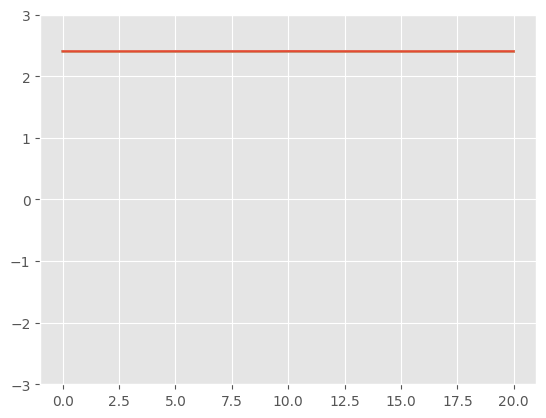

In [234]:
plt.figure()
rabi_phis = np.angle(rabi_complex)
plt.plot(rabi_phis)
plt.ylim([-3,3])

### Time Rabi

Experiments Introduction  
The Time Rabi experiment is used to calibrate the pulse duration required to rotate a superconducting qubit by a desired angle. This example demonstrates how to use instruction set control to sweep the XY drive pulse width while keeping the drive amplitude and frequency fixed.

Experiment Steps
The following steps demonstrate how to perform a Time Rabi measurement:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, pulse width list, drive frequency, drive amplitude, and readout parameters.
3. Build the instruction program for the readout pulse and demodulated acquisition.
4. Build the instruction program for the XY drive pulse with variable pulse width.
5. Configure output, capture mode, trigger period, demodulation frequency, and timing alignment.
6. For each pulse width, execute the XY drive sequence and then perform readout.
7. Acquire and average IQ data at each pulse-width point.
8. Plot the qubit response versus pulse width and determine the pi-pulse and half-pi-pulse durations.

In [137]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.7
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


Time Rabi:   0%|          | 0/47 [00:00<?, ?it/s]

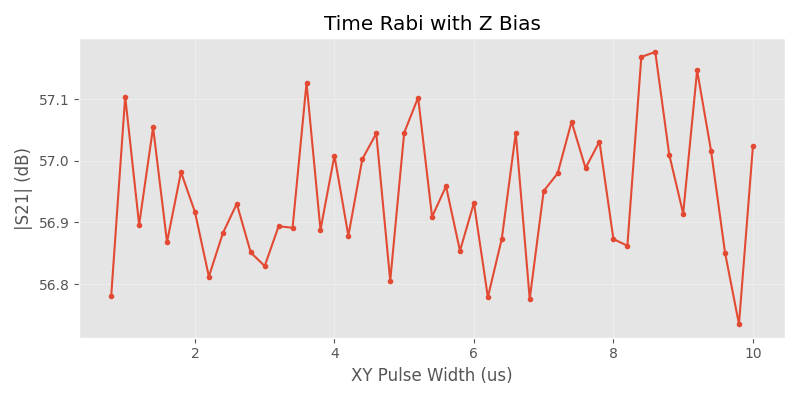

In [138]:
# ============================================================
# Time Rabi
# XY width sweep with Z flux bias in instruction mode
# Instruction timing granularity: 4 ns
# ============================================================

# ---------- 0. Timing alignment ----------
INST_STEP = 4e-9    # instruction timing granularity

def align4(t):
    return round(t / INST_STEP) * INST_STEP


# ---------- 1. nswave kernels ----------
@nw.kernel
def program_cap(capture_start: nw.Var, capture_width: nw.Var):
    nw.wait_for_trigger()
    nw.wait(capture_start)
    nw.capture(capture_width, 0, 0)

    return nw.Kernel


@nw.kernel
def program_probe_out(
    probe_freq: nw.Var,
    probe_width: nw.Var,
    probe_amp: nw.Var,
    probe_out_start: nw.Var,
):
    srate: nw.Var = 8e9
    probe_time: np.ndarray = np.linspace(
        0,
        probe_width,
        int(round(probe_width * srate)),
        endpoint=False,
    )
    probe_wave: np.ndarray = np.cos(2 * np.pi * probe_freq * probe_time)

    frame: nw.Frame = nw.init_frame(0, 0.5 * np.pi)
    probe_envelope: nw.Envelope = nw.ins_envelope(probe_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(probe_out_start)
    nw.play_wave(probe_envelope, probe_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_drive(
    drive_freq: nw.Var,
    drive_width: nw.Var,
    drive_amp: nw.Var,
    z_margin: nw.Var,
):
    srate: nw.Var = 8e9
    drive_wave: np.ndarray = np.ones(int(round(drive_width * srate)))

    frame: nw.Frame = nw.init_frame(drive_freq, 0)
    drive_envelope: nw.Envelope = nw.ins_envelope(drive_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(z_margin)
    nw.play_wave(drive_envelope, drive_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_z(z_width: nw.Var, z_amp: nw.Var):
    srate: nw.Var = 4e9
    z_wave: np.ndarray = z_amp * np.ones(int(round(z_width * srate)))

    z_envelope: nw.Envelope = nw.ins_envelope(z_wave)

    nw.wait_for_trigger()
    nw.play_wave(z_envelope, 1, 0, 0)

    return nw.Kernel


# ---------- 2. Channel and sweep parameters ----------
xy_ch          = "S13-O1"                       # XY drive output channel
z_ch           = "S12-O1"                       # Z flux bias output channel
probe_out_ch   = "S2-O1"                        # readout probe output channel
probe_in_ch    = "S2-I1"                        # readout demod input channel

xy_freq        = 0.1e9                          # XY drive frequency (Hz)
probe_freq     = 0.3e9                          # resonator probe frequency (Hz)

drive_width_list = np.arange(4, 51, 1) * 200e-9 # XY pulse width sweep list
drive_width_list = np.round(drive_width_list / INST_STEP) * INST_STEP

xy_amp         = 0.82                           # XY drive amplitude (normalized)
probe_amp      = 1.0                            # probe pulse amplitude (normalized)
z_amp          = 1.0                            # constant Z bias amplitude

shots          = 1024                           # averages per width point
trig_period    = 800e-6                         # qsync trigger period (s)
cap_num        = 1                              # number of captures per shot
reps           = 1                              # number of XY pulse repetitions per shot

probe_width    = align4(2e-6)                   # readout probe pulse duration (s)
z_margin       = align4(96e-9)                  # Z margin before/after XY pulse

readout_gap    = align4(300e-9)                 # delay from XY pulse end to probe output
capture_gap    = align4(220e-9)                 # delay from probe output to capture start

demod_freq_list = [float(probe_freq)] * 8       # demodulation frequency list


# ---------- 3. Static device configuration ----------
device.set("CaptureMode", 0)
device.set("Shot", int(shots))
device.set("FreqList", demod_freq_list, probe_in_ch)

device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Output", 1, probe_out_ch)

qsync.set("Shot", int(shots))
qsync.set("TrigPeriod", trig_period)


# ---------- 4. Width sweep capture ----------
rabi_iq_list = []

for xy_width in tqdm(drive_width_list, desc="Time Rabi"):

    xy_total = align4(xy_width * reps)

    # Common trigger-based timing.
    xy_start = z_margin
    xy_end = align4(xy_start + xy_total)

    # Readout starts after the current XY pulse, not after Z pulse end.
    probe_out_start = align4(xy_end + readout_gap)
    probe_in_start = align4(probe_out_start + capture_gap)

    # Z bias covers XY pulse, readout pulse, capture window, and final margin.
    z_width = align4(probe_in_start + probe_width + z_margin)

    device.set(
        "ProgramOUT",
        program_z(z_width, z_amp),
        z_ch,
    )                                                   # download Z bias program

    device.set(
        "ProgramIN",
        program_cap(probe_in_start, probe_width),
        probe_in_ch,
    )                                                   # download capture program

    device.set(
        "ProgramOUT",
        program_probe_out(probe_freq, probe_width, probe_amp, probe_out_start),
        probe_out_ch,
    )                                                   # download probe output program

    device.set(
        "ProgramOUT",
        program_drive(xy_freq, xy_total, xy_amp, z_margin),
        xy_ch,
    )                                                   # download XY drive program

    device.set("StartCapture")                         # start capture
    qsync.set("GenerateTrig")                          # fire trigger

    iq_data = device.get("IQ", probe_in_ch, round(shots * cap_num))
    cap_data = iq_data[:, 0::cap_num]                  # select the first capture of each shot

    rabi_iq_list.append(cap_data)


# ---------- 5. Data processing and plotting ----------
rabi_iq_arr = np.array(rabi_iq_list)                    # (width, n_demod, shots)
rabi_complex = rabi_iq_arr.mean(axis=2)                 # -> (width, n_demod)
rabi_db = 20 * np.log10(np.abs(rabi_complex))           # amplitude to dB

plt.figure(figsize=(8, 4))
plt.plot(drive_width_list * reps * 1e6, rabi_db[:, 0], marker="o", markersize=3)
plt.xlabel("XY Pulse Width (us)")
plt.ylabel("|S21| (dB)")
plt.title("Time Rabi with Z Bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(-3.0, 3.0)

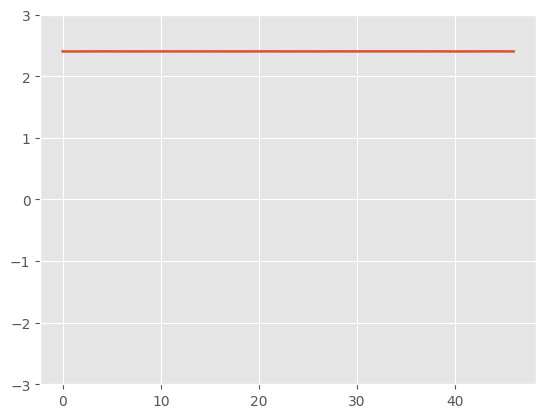

In [237]:
plt.figure()
rabi_phis = np.angle(rabi_complex)
plt.plot(rabi_phis)
plt.ylim([-3,3])

### T1

Experiments Introduction  
The T1 experiment is used to measure the energy relaxation time of a superconducting qubit. This example demonstrates how to use instruction set control to excite the qubit with a pi pulse, wait for a variable delay, and then read out the remaining excited-state population.

Experiment Steps
The following steps demonstrate how to perform a T1 relaxation measurement:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, relaxation delay list, pulse widths, amplitudes, and timing offsets.
3. Build the instruction program for the readout pulse and demodulated acquisition.
4. Build the instruction program for the qubit pi pulse and variable wait delay.
5. Configure output, capture mode, trigger period, demodulation frequency, and timing alignment.
6. For each delay, excite the qubit, wait for the specified relaxation time, and perform readout.
7. Acquire and average IQ data at each delay point.
8. Plot the measured response versus delay and fit the decay curve to extract the T1 time.

In [139]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.7
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


T1:   0%|          | 0/50 [00:00<?, ?it/s]

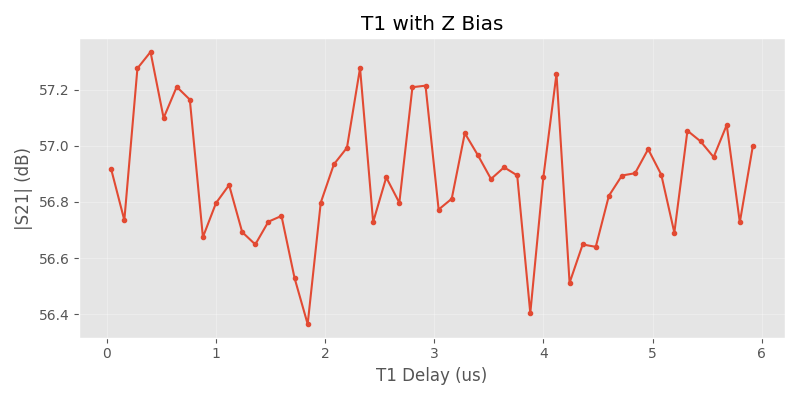

In [140]:
# ---------- 0. Instruction timing helper ----------
INST_STEP = 4e-9

def align4(t):
    return round(t / INST_STEP) * INST_STEP

# ---------- 1. Kernel programs ----------
@nw.kernel
def program_cap(capture_start: nw.Var, capture_width: nw.Var):
    nw.wait_for_trigger()
    nw.wait(capture_start)
    nw.capture(capture_width, 0, 0)

    return nw.Kernel


@nw.kernel
def program_probe_out(
    probe_freq: nw.Var,
    probe_width: nw.Var,
    probe_amp: nw.Var,
    probe_out_start: nw.Var,
):
    srate: nw.Var = 8e9

    probe_time: np.ndarray = np.linspace(
        0,
        probe_width,
        int(round(probe_width * srate)),
        endpoint=False,
    )
    probe_wave: np.ndarray = np.cos(2 * np.pi * probe_freq * probe_time)

    frame: nw.Frame = nw.init_frame(0, 0.5 * np.pi)
    probe_envelope: nw.Envelope = nw.ins_envelope(probe_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(probe_out_start)
    nw.play_wave(probe_envelope, probe_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_drive(
    drive_freq: nw.Var,
    drive_width: nw.Var,
    drive_amp: nw.Var,
    z_margin: nw.Var,
):
    srate: nw.Var = 8e9
    drive_wave: np.ndarray = np.ones(int(round(drive_width * srate)))

    frame: nw.Frame = nw.init_frame(drive_freq, 0)
    drive_envelope: nw.Envelope = nw.ins_envelope(drive_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(z_margin)
    nw.play_wave(drive_envelope, drive_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_z(z_width: nw.Var, z_amp: nw.Var):
    srate: nw.Var = 4e9
    z_wave: np.ndarray = z_amp * np.ones(int(round(z_width * srate)))

    z_envelope: nw.Envelope = nw.ins_envelope(z_wave)

    nw.wait_for_trigger()
    nw.play_wave(z_envelope, 1, 0, 0)

    return nw.Kernel


# ---------- 2. Channel and sweep parameters ----------
xy_ch          = "S13-O1"                       # XY drive output channel
z_ch           = "S12-O1"                       # Z flux bias output channel
probe_out_ch   = "S2-O1"                        # readout probe output channel
probe_in_ch    = "S2-I1"                        # readout demod input channel

xy_freq        = 0.1e9                          # XY drive frequency (Hz)
probe_freq     = 0.3e9                          # resonator probe frequency (Hz)

shots          = 1024                           # averages per delay point
trig_period    = 1200e-6                        # qsync trigger period (s)
cap_num        = 1                              # number of captures per shot

probe_width    = align4(2e-6)                   # readout probe pulse duration
drive_width    = align4(0.4e-6)                 # pi pulse duration

xy_amp         = 0.46                           # pi pulse amplitude
probe_amp      = 1.0                            # probe pulse amplitude
z_amp          = 1.0                            # constant Z bias amplitude

t1_delay_list  = np.arange(1, 151, 3) * 40e-9   # delay between pi pulse and readout
t1_delay_list  = np.round(t1_delay_list / INST_STEP) * INST_STEP

z_margin       = align4(96e-9)                  # Z margin before/after sequence
readout_gap    = align4(220e-9)                 # delay after pi pulse
capture_gap    = align4(300e-9)                 # delay from probe output to capture start

# Define pulse timings on a common trigger-based time axis.
drive_start = z_margin
drive_end = align4(drive_start + drive_width)

# Minimal-change fix:
# Use the longest T1 delay to make one Z pulse cover all sweep points.
max_t1_delay = np.max(t1_delay_list)
max_probe_out_start = align4(drive_end + max_t1_delay + readout_gap)
max_probe_in_start = align4(max_probe_out_start + capture_gap)
z_width = align4(max_probe_in_start + probe_width + z_margin)

demod_freq_list = [float(probe_freq)] * 8


# ---------- 3. Static device configuration ----------
device.set("CaptureMode", 0)
device.set("Shot", int(shots))
device.set("FreqList", demod_freq_list, probe_in_ch)

device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Output", 1, probe_out_ch)

qsync.set("Shot", int(shots))
qsync.set("TrigPeriod", trig_period)

device.set(
    "ProgramOUT",
    program_z(z_width, z_amp),
    z_ch,
)

device.set(
    "ProgramOUT",
    program_drive(xy_freq, drive_width, xy_amp, z_margin),
    xy_ch,
)


# ---------- 4. T1 delay sweep capture ----------
t1_iq_list = []

for t1_delay in tqdm(t1_delay_list, desc="T1"):

    # The probe pulse starts after the pi pulse and the swept T1 delay.
    probe_out_start = align4(drive_end + t1_delay + readout_gap)
    probe_in_start = align4(probe_out_start + capture_gap)

    device.set(
        "ProgramIN",
        program_cap(probe_in_start, probe_width),
        probe_in_ch,
    )

    device.set(
        "ProgramOUT",
        program_probe_out(probe_freq, probe_width, probe_amp, probe_out_start),
        probe_out_ch,
    )

    device.set("StartCapture")
    qsync.set("GenerateTrig")

    iq_data = device.get("IQ", probe_in_ch, round(shots * cap_num))
    cap_data = iq_data[:, 0::cap_num]

    t1_iq_list.append(cap_data)


# ---------- 5. Data processing and plotting ----------
t1_iq_arr = np.array(t1_iq_list)
t1_complex = t1_iq_arr.mean(axis=2)
t1_db = 20 * np.log10(np.abs(t1_complex))

plt.figure(figsize=(8, 4))
plt.plot(t1_delay_list * 1e6, t1_db[:, 0], marker="o", markersize=3)
plt.xlabel("T1 Delay (us)")
plt.ylabel("|S21| (dB)")
plt.title("T1 with Z Bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(-3.0, 3.0)

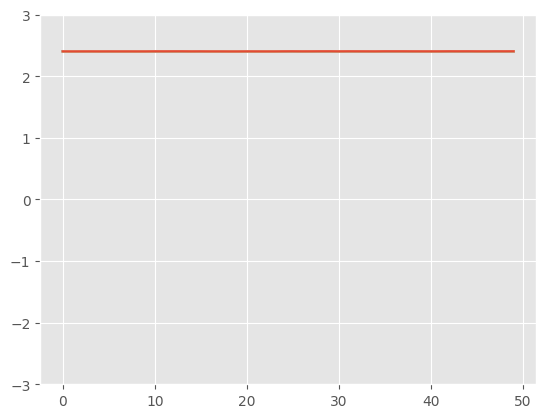

In [240]:
plt.figure()
rabi_phis = np.angle(t1_complex)
plt.plot(rabi_phis)
plt.ylim([-3,3])

### T2

Experiments Introduction  
The T2 experiment is used to measure the dephasing time of a superconducting qubit. This example demonstrates how to use instruction set control to run a Ramsey sequence by applying two half-pi pulses separated by a variable delay, followed by readout of the qubit state.

Experiment Steps
The following steps demonstrate how to perform a Ramsey T2 measurement:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the XY drive channel, Z bias channel, readout output channel, readout input channel, Ramsey delay list, pulse widths, amplitudes, and timing offsets.
3. Build the instruction program for the readout pulse and demodulated acquisition.
4. Build the instruction program for the two half-pi XY pulses separated by the Ramsey delay.
5. Configure output, capture mode, trigger period, demodulation frequency, and timing alignment.
6. For each Ramsey delay, execute the XY sequence, wait for the programmed delay, and perform readout.
7. Acquire and average IQ data at each delay point.
8. Plot the Ramsey oscillation or envelope versus delay and extract the qubit dephasing time.

In [141]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.8
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


In [142]:
# ---------- 0. Instruction timing helper ----------
INST_STEP = 4e-9

def align4(t):
    return round(t / INST_STEP) * INST_STEP


# ---------- 2. Kernel programs ----------
@nw.kernel
def program_cap(capture_start: nw.Var, capture_width: nw.Var):
    nw.wait_for_trigger()
    nw.wait(capture_start)
    nw.capture(capture_width, 0, 0)

    return nw.Kernel


@nw.kernel
def program_probe_out(
    probe_freq: nw.Var,
    probe_width: nw.Var,
    probe_amp: nw.Var,
    probe_out_start: nw.Var,
):
    srate: nw.Var = 8e9

    probe_time: np.ndarray = np.linspace(
        0,
        probe_width,
        int(round(probe_width * srate)),
        endpoint=False,
    )
    probe_wave: np.ndarray = np.cos(2 * np.pi * probe_freq * probe_time)

    frame: nw.Frame = nw.init_frame(0, 0.5 * np.pi)
    probe_envelope: nw.Envelope = nw.ins_envelope(probe_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(probe_out_start)
    nw.play_wave(probe_envelope, probe_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_drive(
    drive_freq: nw.Var,
    half_drive_width: nw.Var,
    drive_amp: nw.Var,
    z_margin: nw.Var,
    ramsey_delay: nw.Var,
):
    srate: nw.Var = 8e9
    drive_wave: np.ndarray = np.ones(int(round(half_drive_width * srate)))

    frame: nw.Frame = nw.init_frame(drive_freq, 0)
    drive_envelope: nw.Envelope = nw.ins_envelope(drive_wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(z_margin)
    nw.play_wave(drive_envelope, drive_amp, 0, 0)
    nw.wait(ramsey_delay)
    nw.play_wave(drive_envelope, drive_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_z(z_width: nw.Var, z_amp: nw.Var):
    srate: nw.Var = 4e9
    z_wave: np.ndarray = z_amp * np.ones(int(round(z_width * srate)))

    z_envelope: nw.Envelope = nw.ins_envelope(z_wave)

    nw.wait_for_trigger()
    nw.play_wave(z_envelope, 1, 0, 0)

    return nw.Kernel


# ---------- 3. Experiment parameters ----------
xy_freq        = 0.1e9
detuning_freq  = 1e6
xy_freq_d      = xy_freq + detuning_freq
probe_freq     = 0.3e9

shots          = 1024
trig_period    = 1200e-6
cap_num        = 1

probe_width     = align4(2e-6)
half_drive_width = align4(0.2e-6)

xy_amp          = 0.82
probe_amp       = 1.0

# Fixed Z bias value for the whole T2 Ramsey experiment.
z_amp           = 1.0

ramsey_delay_list = np.arange(1, 101, 1) * 40e-9
ramsey_delay_list = np.round(ramsey_delay_list / INST_STEP) * INST_STEP

z_margin       = align4(96e-9)
readout_gap    = align4(220e-9)
capture_gap    = align4(300e-9)

# Use the longest Ramsey delay to make one fixed Z program cover all sweep points.
max_ramsey_delay = np.max(ramsey_delay_list)
max_qubit_active = align4(2 * half_drive_width + max_ramsey_delay)
max_probe_out_start = align4(z_margin + max_qubit_active + readout_gap)
max_probe_in_start = align4(max_probe_out_start + capture_gap)
z_width = align4(max_probe_in_start + probe_width + z_margin)

demod_freq_list = [float(probe_freq)] * 8


# ---------- 4. Static device configuration ----------
device.set("CaptureMode", 0)
device.set("Shot", int(shots))
device.set("FreqList", demod_freq_list, probe_in_ch)

device.set("Output", 1, xy_ch)
device.set("Output", 1, z_ch)
device.set("Output", 1, probe_out_ch)

qsync.set("Shot", int(shots))
qsync.set("TrigPeriod", trig_period)

# Fixed Z bias program, downloaded once.
device.set(
    "ProgramOUT",
    program_z(z_width, z_amp),
    z_ch,
)


# ---------- 5. Ramsey delay sweep capture ----------
t2_iq_list = []

for ramsey_delay in tqdm(ramsey_delay_list, desc="T2 Ramsey"):

    qubit_active = align4(2 * half_drive_width + ramsey_delay)

    # Readout starts after the current Ramsey sequence, not after fixed Z end.
    probe_out_start = align4(z_margin + qubit_active + readout_gap)
    probe_in_start = align4(probe_out_start + capture_gap)

    device.set(
        "ProgramOUT",
        program_drive(xy_freq_d, half_drive_width, xy_amp, z_margin, ramsey_delay),
        xy_ch,
    )

    device.set(
        "ProgramIN",
        program_cap(probe_in_start, probe_width),
        probe_in_ch,
    )

    device.set(
        "ProgramOUT",
        program_probe_out(probe_freq, probe_width, probe_amp, probe_out_start),
        probe_out_ch,
    )

    device.set("StartCapture")
    qsync.set("GenerateTrig")

    iq_data = device.get("IQ", probe_in_ch, round(shots * cap_num))
    cap_data = iq_data[:, 0::cap_num]

    t2_iq_list.append(cap_data)


# ---------- 6. Data processing and plotting ----------
t2_iq_arr = np.array(t2_iq_list)
t2_complex = t2_iq_arr.mean(axis=2)
t2_db = 20 * np.log10(np.abs(t2_complex))

plt.figure(figsize=(8, 4))
plt.plot(ramsey_delay_list * 1e6, t2_db[:, 0], marker="o", markersize=3)
plt.xlabel("Ramsey Delay (us)")
plt.ylabel("|S21| (dB)")
plt.title("T2 Ramsey with Fixed Z Bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

T2 Ramsey:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

(-3.0, 3.0)

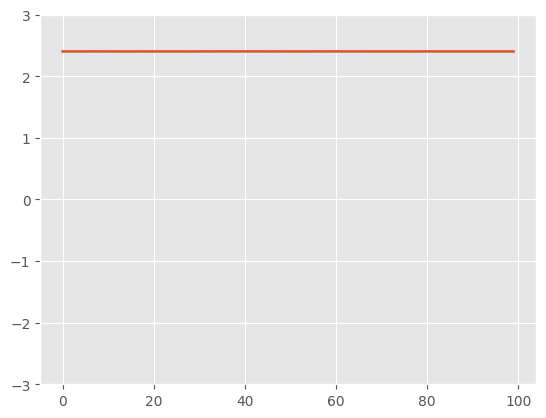

In [245]:
plt.figure()
rabi_phis = np.angle(t2_complex)
plt.plot(rabi_phis)
plt.ylim([-3,3])

### Activate Reset

Experiments Introduction
The Active Reset experiment is used to reduce the initialization time of a superconducting qubit by repeatedly reading out the qubit state and conditionally applying a reset pulse when the excited state is detected. This example demonstrates how to use instruction set control, hardware judge logic, and feedback-related configuration to implement a closed-loop reset sequence.

Experiment Steps
The following steps demonstrate how to perform active reset with repeated readout, judgment, and conditional XY reset pulses:
1. Initialize the system and synchronize the MCI and QSYNC drivers.
2. Define the readout channel, XY reset channel, capture channel, judge threshold, judge rotation, judge channels, number of reset rounds, and timing parameters.
3. Configure feedback-related registers and enable the required feedback path.
4. Build the readout instruction program to play the probe waveform and acquire IQ data.
5. Build the conditional reset instruction program to apply an XY pulse only when the judge result indicates the excited state.
6. Combine readout, judge, delay, and conditional reset operations into the active reset sequence.
7. Start capture, generate triggers, and execute the active reset program.
8. Acquire and analyze the resulting IQ data to evaluate reset performance and residual excited-state population.

In [143]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()
plt.style.use('ggplot') 

# ---------- 1.1 Device address ----------
deviceIP = "172.16.153.203"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 2,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.203开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.203 opened successfully
*********设备172.16.153.203开启成功*********
device_type: pqtm
backend_version: v2.11.7-9-gbb67076
ad_num: 5
da_num: 27
cpu_temp: nan
memory_use: 7.8
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4', 'S3-I1']
172.16.153.203开启成功
device: 172.16.153.203系统同步过程 0x3100001a 执行失败
System synchronization FAILED


In [148]:
# ============================================================
# Active Reset
# Repeated readout, judge, and conditional XY reset pulse
# Instruction timing granularity: 4 ns
# ============================================================

# ---------- 0. Timing alignment ----------
INST_STEP = 4e-9

def align4(t):
    return round(t / INST_STEP) * INST_STEP


# ---------- 1. Channel and experiment parameters ----------
probe_out_ch = "S2-O1"
probe_in_ch  = "S2-I1"
xy_ch        = "S13-O1"

drive_width  = align4(1e-6)
drive_amp    = 1.0
drive_freq   = 0.3e9

probe_width  = align4(1e-6)
probe_amp    = 1.0
probe_freq   = 0.3e9

readout_gap  = align4(100e-9)
round_gap    = align4(2e-6)

judge_rotation  = 1 + 0j
judge_threshold = 784817
judge_channels  = [0, 1, 2, 3, 4, 5, 6, 7]

shots  = 0xffffff0
period = 400e-6

demod_freq_list = [float(probe_freq)] * 8


# ---------- 2. Feedback and route configuration ----------
qsync.set("GT_pd", 1)

feedback_reset_addr = 0x01F0_0000 + 2 * 4

device.set("CustomALite", [feedback_reset_addr, 1], probe_out_ch)
time.sleep(1e-5)
device.set("CustomALite", [feedback_reset_addr, 0], probe_out_ch)
time.sleep(3)

device.set("CustomALite", [feedback_reset_addr, 1], xy_ch)
time.sleep(1e-5)
device.set("CustomALite", [feedback_reset_addr, 0], xy_ch)
time.sleep(1e-5)

device.set("TerminateUpload")

device.set("SetRoute", [probe_out_ch, xy_ch])


# ---------- 3. nswave kernels ----------
@nw.kernel
def program_xy(
    drive_width: nw.Var,
    drive_amp: nw.Var,
    drive_freq: nw.Var,
    probe_width: nw.Var,
    readout_gap: nw.Var,
    round_gap: nw.Var,
):
    judge_reg: nw.Reg = 0
    srate: nw.Var = 8e9

    drive_wave: np.ndarray = np.ones(int(round(drive_width * srate)))

    frame: nw.Frame = nw.init_frame(drive_freq, 0.5 * np.pi)
    envelope: nw.Envelope = nw.ins_envelope(drive_wave)

    nw.wait_for_trigger()
    nw.reset_frame()

    nw.play_wave(envelope, 1, 0, 0)

    nw.wait(readout_gap)
    nw.wait(probe_width)
    nw.wait(round_gap)

    judge_reg = nw.receive(1)
    if (judge_reg == 0xff):
        nw.play_wave(envelope, drive_amp, 0, 0)
    else:
        nw.wait(drive_width)

    nw.wait(round_gap)
    nw.wait(probe_width)

    judge_reg = nw.receive(1)
    if (judge_reg == 0xff):
        nw.play_wave(envelope, drive_amp, 0, 0)
    else:
        nw.wait(drive_width)

    nw.wait(round_gap)
    nw.wait(probe_width)

    judge_reg = nw.receive(1)
    if (judge_reg == 0xff):
        nw.play_wave(envelope, drive_amp, 0, 0)
    else:
        nw.wait(drive_width)

    return nw.Kernel


@nw.kernel
def program_probe_out(
    probe_width: nw.Var,
    probe_amp: nw.Var,
    probe_freq: nw.Var,
    drive_width: nw.Var,
    readout_gap: nw.Var,
    round_gap: nw.Var,
):
    srate: nw.Var = 8e9

    probe_time: np.ndarray = np.linspace(
        0,
        probe_width,
        int(round(probe_width * srate)),
        endpoint=False,
    )
    probe_wave: np.ndarray = np.cos(2 * np.pi * probe_freq * probe_time)

    frame: nw.Frame = nw.init_frame(0, 0.5 * np.pi)
    envelope: nw.Envelope = nw.ins_envelope(probe_wave)

    nw.wait_for_trigger()
    nw.reset_frame()

    nw.wait(drive_width)
    nw.wait(readout_gap)
    nw.play_wave(envelope, probe_amp, 0, 0)

    nw.wait(round_gap)
    nw.wait(drive_width)
    nw.wait(readout_gap)
    nw.play_wave(envelope, probe_amp, 0, 0)

    nw.wait(round_gap)
    nw.wait(drive_width)
    nw.wait(readout_gap)
    nw.play_wave(envelope, probe_amp, 0, 0)

    return nw.Kernel


@nw.kernel
def program_probe_in(
    probe_width: nw.Var,
    drive_width: nw.Var,
    readout_gap: nw.Var,
    round_gap: nw.Var,
    judge_rotation: nw.Var,
    judge_threshold: nw.Var,
    judge_channels: nw.Var,
):
    judge_reg: nw.Reg = 0

    nw.set_judge(judge_rotation, judge_threshold, judge_channels)

    nw.wait_for_trigger()

    nw.wait(drive_width)
    nw.wait(readout_gap)
    judge_reg = nw.capture(probe_width, 0, 0)
    nw.send(judge_reg)

    nw.wait(round_gap)
    nw.wait(drive_width)
    nw.wait(readout_gap)
    judge_reg = nw.capture(probe_width, 0, 0)
    nw.send(judge_reg)

    nw.wait(round_gap)
    nw.wait(drive_width)
    nw.wait(readout_gap)
    judge_reg = nw.capture(probe_width, 0, 0)
    nw.send(judge_reg)

    return nw.Kernel


# ---------- 4. Device program configuration ----------
device.set("CaptureMode", 0)
device.set("Shot", int(shots))
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", demod_freq_list, probe_in_ch)

device.set("Output", 1, probe_out_ch)
device.set("Output", 1, xy_ch)

qsync.set("Shot", int(shots))

device.set(
    "ProgramIN",
    program_probe_in(
        probe_width,
        drive_width,
        readout_gap,
        round_gap,
        judge_rotation,
        judge_threshold,
        judge_channels,
    ),
    probe_in_ch,
)

device.set(
    "ProgramOUT",
    program_probe_out(
        probe_width,
        probe_amp,
        probe_freq,
        drive_width,
        readout_gap,
        round_gap,
    ),
    probe_out_ch,
)

device.set(
    "ProgramOUT",
    program_xy(
        drive_width,
        drive_amp,
        drive_freq,
        probe_width,
        readout_gap,
        round_gap,
    ),
    xy_ch,
)

In [145]:
device.set('CaptureMode', 0)
shots = 1024
qsync.set('Shot', shots)
device.set('Shot', shots)
device.set('StartCapture')
qsync.set('GenerateTrig', 100e-6)
IQ_data = device.get("IQ", probe_in_ch, shots*3)
print(IQ_data.mean())


(-1910.347-1891.4531j)


In [86]:
device.set('CaptureMode', 2)
shots = 1024
qsync.set('Shot', shots)
device.set('Shot', shots)
device.set('StartCapture')
qsync.set('GenerateTrig', 100e-6)
judge_data = device.get("Judgment", probe_in_ch, shots*3)
print(judge_data)

[255 255 255 ... 255 255 255]


In [149]:
device.set('CaptureMode', 0)
shots = 1024000
qsync.set('Shot', shots)
device.set('Shot', shots)
# device.set('StartCapture')
qsync.set('GenerateTrig', 100e-6)
